<div style="text-align: center;">
    <h1>Python and Advanced Data Sciences: Final Project</h1>
    <p><strong>Instructor:</strong> Batuhan Can</p>
    <p><strong>Members:</strong> Maximillian Seidlitz, Niklas Matusik, Bilal Mert, Bui Ngoc Minh Quach</p>
    <p><strong>Due Date:</strong> 21.07.2026</p>
</div>

# PyTUMs: Predicting NOVA Food Processing Groups & Nutri-Score Grades Using Open Food Facts Data

**Final Project — PyTUMs**

**Team & Contributions:** 

| Section | Contributed by |
|---|---|
| 1. Domain Knowledge | *Bilal, Minh* |
| 2. Problem Statement & Hypotheses | *Bilal, Minh* |
| 3–8. Data Extraction, Cleaning, Preprocessing | *Bilal, Minh* |
| 9. EDA | *Bilal, Minh* |
| 10–11. ML Preprocessing & Clustering | *Niklas, Max* |
| 12–14. ML Models, Comparison, Tuning (NOVA) | *Niklas, Max* |
| 15. Nutri-Score (Secondary Problem) | *Niklas, Max* |
| 16. Conclusion | *Niklas, Max* |


## 1. Domain Knowledge

### 1.1 NOVA Classification (Main Focus)

The NOVA classification system categorizes foods according to the extent and purpose of industrial processing rather than nutrient composition alone (Monteiro et al., 2016). It distinguishes four groups: unprocessed or minimally processed foods, processed culinary ingredients, processed foods, and ultra-processed foods (Monteiro et al., 2016; Romero Ferreiro et al., 2021). 

- Group 1 includes foods such as fruit, vegetables, milk, grains, meat, or eggs (Monteiro et al., 2016; Sarda et al., 2024). 
- Group 2 consists of culinary ingredients such as oils, butter, sugar, or salt (Monteiro et al., 2016; Sarda et al., 2024).
- Group 3 includes processed foods such as cheese, canned vegetables, or freshly baked bread (Monteiro et al., 2016; Sarda et al., 2024).
- Group 4 contains ultra-processed food and drink products, which are typically industrial formulations with several ingredients, additives, and substances not commonly used in home cooking (Monteiro et al., 2016; Sarda et al., 2024).

NOVA is the main focus of this project because it captures a different dimension of food evaluation than nutrient-based labels. While nutrient profiling systems evaluate nutritional composition, NOVA focuses on food processing and industrial formulation (Monteiro et al., 2019; Romero Ferreiro et al., 2021; Sarda et al., 2024). This makes NOVA a more complex prediction target, because it is not directly calculated from values such as energy, sugar, saturated fat, or salt. Instead, NOVA depends more strongly on ingredient lists, additives, and processing-related characteristics (Monteiro et al., 2016; Menichetti et al., 2023). Therefore, this project uses NOVA groups as the main target variable and extends the nutrient-based features with additives_n and ingredients_n, which are conceptually closer to the NOVA definition.

NOVA as a theoretical framework is based on an assessment of ingredients, processing methods, and product formulation (Monteiro et al., 2016; Monteiro et al., 2019). However, the nova_group variable used in this project is not manually assigned. Instead, Open Food Facts derives it using a rule-based algorithm that relies substantially on product categories and additive-related information. Because additives_n and main_category_grouped are also included as predictors, some information used to construct the target may also be present among the model inputs. This creates a potential risk of target leakage and may inflate predictive performance. Section 13.3 addresses this issue through a control analysis that compares model performance with and without these potentially overlapping features.


### 1.2 Nutri-Score (Secondary Benchmark)

Nutri-Score is a front-of-pack nutrition label that classifies packaged food products from A to E, where A represents the most favorable nutritional profile and E the least favorable. The score is based on a nutrient profiling algorithm that balances unfavorable components, such as energy, saturated fat, sugar, and salt, with favorable components, such as fiber, protein, and fruit or vegetable content (van der Bend et al., 2022; Merz et al., 2024).

Nutri-Score is intended to simplify nutrition information and help consumers compare food products more easily. However, it should be interpreted carefully because products from different food groups naturally differ in their nutritional composition. Therefore, comparisons within similar product groups can be more meaningful than comparisons across very different categories (van der Bend et al., 2022; Merz et al., 2024). In 2023, the Nutri-Score algorithm was updated to better align with food-based dietary guidelines and to improve discrimination within selected product groups, especially for products high in sugar, salt, or saturated fat (Merz et al., 2024).

In this project, Nutri-Score is included as a secondary benchmark. Since it is directly based on nutritional components, it is expected to be more predictable from nutrient features than NOVA. Comparing both targets allows the project to examine how well the same product information predicts a nutrient-based label versus a processing-based label (Romero Ferreiro et al., 2021; Sarda et al., 2024.



## 2. Problem Statement, Project Goals & Hypotheses

### 2.1 Problem Statement & Project Goals

This project investigates whether food classification systems can be predicted from structured product information in the Open Food Facts dataset (Hugging Face, 2026). The main focus is the prediction of NOVA food processing groups. NOVA classifies foods according to the extent and purpose of industrial processing, which makes it conceptually different from nutrient-based food labels (Monteiro et al., 2016; Romero Ferreiro et al., 2021). Based on this disctinction, the project is guided by the following main research question: 

**Can the NOVA processing group of a food product be predicted from its nutrient values per 100 g, together with information on the number of additives and ingredients?**

As a secondary supervised learning problem, the project also predicts Nutri-Score grades from the same product information. Nutri-Score is included as a benchmark because it is directly based on nutritional components such as energy, sugar, saturated fat, salt, fiber, and protein (van der Bend et al., 2022; Merz et al., 2024). Comparing NOVA and Nutri-Score prediction therefore allows the project to examine whether the same feature set predicts a nutrient-based label and a processing-based label with different levels of accuracy.
In addition, the project includes an unsupervised learning component. Clustering is used to explore whether products can be grouped into meaningful product profiles based on nutrient values and whether these clusters resemble Nutri-Score or NOVA more closely. This helps assess whether nutritional patterns alone capture processing-related differences.

The main project goals are:
1. Build a cleaned and shuffled sample from the Open Food Facts dataset.
2. Develop domain knowledge on both NOVA and Nutri-Score and translate it into testable hypotheses.
3. Build, evaluate, and tune several machine learning models for NOVA classification, including ensemble and neural-network-based approaches.
4. Use Nutri-Score classification as a contrasting benchmark.
5. Apply clustering to examine whether nutrient-based product groups align more closely with Nutri-Score or NOVA.
6. Interpret the results using existing literature and discuss relevant dataset and methodological limitations.

### 2.2 Hypotheses

Based on the domain knowledge and previous literature, four testable hypotheses are formulated.

**H1: Products with a higher number of additives and ingredients are more likely to belong to NOVA group 4.**  
*This expectation follows from the NOVA definition of ultra-processed foods, which emphasizes industrial formulations, additives, and ingredients not commonly used in home cooking (Monteiro et al., 2016; Sarda et al., 2024). Previous machine learning studies also show that processing levels can be predicted from structured food product data, including nutrient and additive-related patterns (Menichetti et al., 2023).*

**H2: NOVA groups are expected to be more difficult to predict than Nutri-Score grades.**  
*Nutri-Score is directly based on nutrient values, whereas NOVA captures the degree of food processing and depends more strongly on ingredient lists, additives, and formulation characteristics (Monteiro et al., 2016; Merz et al., 2024). Therefore, the same nutrient-based feature set should predict Nutri-Score more accurately than NOVA.*

**H3: Nutri-Score and NOVA are related but not identical.**  
*A product can have a favorable nutritional profile while still being ultra-processed, or it can be less processed while receiving a less favorable Nutri-Score. Previous research shows that ultra-processed foods can appear across all Nutri-Score grades, indicating that nutritional quality and processing level represent complementary dimensions of food evaluation (Romero Ferreiro et al., 2021; Sarda et al., 2024).*

**H4: Nutrient-based clustering is expected to resemble Nutri-Score more closely than NOVA.**  
*Since the clustering features are mainly nutrient values, they are conceptually closer to the Nutri-Score logic than to the NOVA logic. NOVA depends more strongly on processing-related information, while Nutri-Score is directly derived from nutritional composition (van der Bend et al., 2022; Monteiro et al., 2016; Merz et al., 2024).*

These hypotheses guide the exploratory analysis, supervised classification models, clustering analysis, and final interpretation of the project results.


## 3. Project Setup and Library Imports

Install the project dependencies once before running this notebook (from the repository root):

```bash
pip install -r requirements.txt
```

All required packages are listed in `requirements.txt` (e.g. `datasets`, `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `scipy`, `pyarrow`).

In the next cell, we import all required Python libraries. The `datasets` library is used to load the Open Food Facts dataset directly from Hugging Face. Pandas and NumPy are used for data manipulation. Matplotlib and Seaborn are used for data visualization. We additionally import scikit-learn modules for preprocessing pipelines, clustering, and the six classification models used in Sections 10-14.



In [1]:
# Import data handling libraries
import pandas as pd
import numpy as np

# Standard library helpers needed for reservoir sampling and caching the raw sample
import os
import json
import random
import warnings
from datetime import datetime

# Import Hugging Face dataset loader
from datasets import load_dataset

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn building blocks for preprocessing, clustering, and models
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    adjusted_rand_score, silhouette_score
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Reproducibility: fixed seed for the entire notebook run
SEED = 42
np.random.seed(SEED)

# Suppress the sklearn.utils.parallel joblib UserWarning that clutters the output of the GridSearchCV cells in Section 14 (n_jobs=-1 triggers it on every worker). Purely cosmetic, does not affect results.
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 60)
print("Setup complete.")

/Users/maxseidlitz/1-CODING/TUM-Uni/PythonandAdvancedDataScience/Nutrition_PythonAdvDataScience/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


## 4. Dataset Access and Data Extraction

This project uses the Open Food Facts product database, accessed through the Hugging Face `datasets` library. Open Food Facts is an open, collaborative food database containing product-level information on packaged foods, including nutritional values, ingredient lists, additives, product categories, Nutri-Score grades, and NOVA food processing groups. Previous studies have successfully used Open Food Facts to investigate the relationship between nutrient profiling systems and food processing classifications, demonstrating the suitability of the database for comparative food classification research (Romero Ferreiro et al., 2021; Sarda et al., 2024).

The Open Food Facts database contains several million food products and is continuously updated (Hugging Face, 2026). To efficiently access such a large dataset without downloading it in its entirety, the data are loaded in streaming mode using the Hugging Face `datasets` library. Streaming enables sequential access to the dataset while keeping memory requirements low, making it well suited for large-scale data analysis in notebook environments (Hugging Face, 2026).

Although streaming provides efficient access to the complete database, processing every available product would still be computationally expensive and unnecessary for the objectives of this project. Therefore, a representative sample of **100,000** food products is used for the subsequent analyses. Sampling is a common strategy in large-scale data analysis, as it substantially reduces computational cost while preserving sufficient information for exploratory analysis and machine learning when the sample is representative of the underlying population (Salloum et al., 2019).

To obtain an unbiased sample from the streamed dataset, **reservoir sampling (Algorithm R)** is employed. Unlike buffered shuffling, which only randomizes observations within a limited in-memory window, reservoir sampling processes the complete data stream once and ensures that every product has the same probability of being included in the final sample, regardless of its position in the dataset. This produces a statistically representative sample while remaining compatible with streaming-based data access (Vitter, 1985).

Because scanning the complete data stream requires considerable runtime, the sampled dataset is cached locally after its initial creation. Subsequent executions of the notebook load the cached sample directly from disk, ensuring reproducibility while avoiding repeated processing of the full Open Food Facts database.


In [2]:
# Load the Open Food Facts product database from Hugging Face in streaming mode
# Streaming avoids downloading the full multi-million-row dataset at once
dataset = load_dataset(
    "openfoodfacts/product-database",
    split="food",
    streaming=True
)
print("Dataset connection successful.")


Dataset connection successful.


In [3]:
%%time
# Sample size increased from 50,000 to 100,000 on supervisor feedback ("more data would be better").
# Reduce this if a full reservoir-sampling pass becomes too slow on your machine/connection.
SAMPLE_SIZE = 100_000

# Local cache: the reservoir-sampling pass below streams through the *entire*
# database once, which is slow. We cache the result so this only has to run
# once per machine; every later run of this notebook (or by a teammate) can
# just reload the exact same sample from disk instead of re-streaming it.
# This also makes the sample a fixed, inspectable artifact: "this is the
# dataset we actually looked at", independent of what Open Food Facts serves
# on a later day.
RAW_SAMPLE_PATH = "openfoodfacts_raw_sample.parquet"
RAW_SAMPLE_META_PATH = "openfoodfacts_raw_sample_meta.json"

if os.path.exists(RAW_SAMPLE_PATH):
    df = pd.read_parquet(RAW_SAMPLE_PATH)
    print(f"Loaded cached raw sample from '{RAW_SAMPLE_PATH}': {df.shape}")
    if os.path.exists(RAW_SAMPLE_META_PATH):
        with open(RAW_SAMPLE_META_PATH) as f:
            print("Sampling metadata:", json.load(f))
else:
    # Reservoir sampling (Algorithm R): draws a uniform random sample of fixed
    # size from a stream of unknown/huge length without ever holding the full
    # stream in memory. Every product seen so far has exactly SAMPLE_SIZE / n_seen
    # probability of being in the reservoir at any point, which is what makes
    # the final sample a true random sample of the whole database (see the
    # markdown cell above for why the previous shuffle-buffer approach did not
    # have this property).
    rng = random.Random(SEED)
    reservoir = []
    n_seen = 0

    for row in dataset:
        n_seen += 1
        if len(reservoir) < SAMPLE_SIZE:
            reservoir.append(row)
        else:
            j = rng.randint(0, n_seen - 1)
            if j < SAMPLE_SIZE:
                reservoir[j] = row
        if n_seen % 250_000 == 0:
            print(f"...{n_seen:,} products streamed so far")

    df = pd.DataFrame(reservoir)

    # Parquet (not CSV) is used because several columns (e.g. 'nutriments',
    # 'categories_tags') hold nested lists/dicts. CSV would flatten these into
    # plain strings on reload, breaking all downstream extraction logic;
    # Parquet preserves the original nested structure.
    df.to_parquet(RAW_SAMPLE_PATH, index=False)

    with open(RAW_SAMPLE_META_PATH, "w") as f:
        json.dump({
            "sample_size": SAMPLE_SIZE,
            "rows_streamed_total": n_seen,
            "seed": SEED,
            "method": "reservoir sampling (Algorithm R) over the full streamed dataset",
            "created_at": datetime.now().isoformat(timespec="seconds"),
        }, f, indent=2)

    print(f"Reservoir sampling complete. Streamed {n_seen:,} products, kept {len(reservoir):,}.")
    print(f"Raw sample cached as Parquet: '{RAW_SAMPLE_PATH}' (metadata: '{RAW_SAMPLE_META_PATH}')")

print("Dataset shape:", df.shape)
df.head()


Loaded cached raw sample from 'openfoodfacts_raw_sample.parquet': (100000, 111)
Sampling metadata: {'sample_size': 100000, 'rows_streamed_total': 4610617, 'seed': 42, 'method': 'reservoir sampling (Algorithm R) over the full streamed dataset', 'created_at': '2026-07-16T15:09:36'}
Dataset shape: (100000, 111)
CPU times: user 2.14 s, sys: 243 ms, total: 2.39 s
Wall time: 1.85 s


,additives_n,additives_tags,allergens_tags,brands_tags,brands,categories,categories_tags,categories_properties,checkers_tags,ciqual_food_name_tags,cities_tags,code,compared_to_category,complete,completeness,correctors_tags,countries_tags,created_t,creator,data_quality_errors_tags,data_quality_info_tags,data_quality_warnings_tags,data_sources_tags,environmental_score_data,environmental_score_grade,environmental_score_score,environmental_score_tags,editors,emb_codes_tags,emb_codes,...,packagings_complete,packaging_recycling_tags,packaging_shapes_tags,packaging_tags,packaging_text,packaging,packagings,photographers,popularity_key,popularity_tags,product_name,product_quantity_unit,product_quantity,purchase_places_tags,quantity,rev,scans_n,serving_quantity,serving_size,states_tags,stores_tags,stores,traces_tags,unique_scans_n,unknown_ingredients_n,unknown_nutrients_tags,vitamins_tags,with_non_nutritive_sweeteners,with_sweeteners,schema_version
0,2.0,"[en:e14xx, en:e325]",[en:eggs],[xx:maitre-coq],Maître CoQ,Farces,[en:stuffing],"{'ciqual_food_code': None, 'agribalyse_food_co...",[],[unknown],[chavagnes-en-paillers-vendee-france],3230890018107,en:stuffing,0,0.8625,"[ldc, fixbot, packbot]",[en:france],1549800655,ldc,[],"[en:no-packaging-data, en:ingredients-percent-...",[en:environmental-score-packaging-packaging-da...,"[producer-ldc, producers]","{""status"":""unknown"",""agribalyse"":{""warning"":""m...",unknown,NaN,[unknown],None,[emb-85065b],EMB 85065B,...,None,[],[],[en:fresh],[],Frais,[],None,0,None,"[{'lang': 'main', 'text': 'Farce cuisinée aux ...",g,400,None,400 g,6,NaN,NaN,NaN,"[en:to-be-completed, en:nutrition-facts-comple...",None,NaN,"[en:celery, en:gluten, en:milk, en:mustard, en...",NaN,1.0,[],[],NaN,NaN,1003
1,NaN,None,[],[xx:aldi-bio],Aldi Bio,NaN,None,"{'ciqual_food_code': None, 'agribalyse_food_co...",[],None,None,4061462577697,NaN,0,0.3000,[smoothie-app],[en:switzerland],1762503645,macrofactor,[],"[en:no-packaging-data, en:food-groups-1-unknow...",[en:serving-quantity-defined-but-quantity-unde...,"[app-macrofactor, apps, app-smoothie-openfoodf...","{""grade"":""unknown"",""missing"":{""categories"":1,""...",unknown,NaN,[unknown],None,None,NaN,...,None,[],[],None,[],NaN,[],None,0,None,"[{'lang': 'main', 'text': 'Muesli Dinkel Schok...",NaN,NaN,None,NaN,2,NaN,100,1 portion (100 g),"[en:to-be-completed, en:nutrition-facts-comple...",None,NaN,[],NaN,NaN,[],None,NaN,NaN,1003
2,NaN,None,[],[xx:Nutricost],Nutricost,NaN,None,"{'ciqual_food_code': None, 'agribalyse_food_co...",[],None,None,0810014673776,NaN,0,0.3750,[macrofactor],[en:united-states],1721090089,macrofactor,[],"[en:no-packaging-data, en:food-groups-1-unknow...","[en:serving-quantity-under-1g, en:serving-quan...","[app-macrofactor, apps]","{""agribalyse"":{""warning"":""missing_agribalyse_m...",unknown,NaN,[unknown],None,None,NaN,...,None,[],[],None,[],NaN,[],None,0,None,"[{'lang': 'main', 'text': 'Lycopene'}, {'lang'...",NaN,NaN,None,NaN,8,NaN,0.02,1 softgel (0.02 g),"[en:to-be-completed, en:nutrition-facts-comple...",None,NaN,[],NaN,NaN,[],None,NaN,NaN,1004
3,NaN,None,[],None,NaN,NaN,None,"{'ciqual_food_code': None, 'agribalyse_food_co...",[],None,None,2060010048971,NaN,0,0.2750,[roboto-app],[en:italy],1636673043,kiliweb,[en:nutrition-packaging-as-sold-100g-energy-va...,"[en:no-packaging-data, en:food-groups-1-unknow...",[en:nutrition-packaging-as-sold-100g-energy-va...,"[app-yuka, apps]","{""agribalyse"":{""warning"":""missing_agribalyse_m...",unknown,NaN,[unknown],None,None,NaN,...,None,[],[],None,[],NaN,[],None,0,None,"[{'lang': 'main', 'text': 'Jamon serrsmo'}, {'...",NaN,NaN,None,NaN,8,NaN,NaN,NaN,"[en:to-be-completed, en:nutrition-facts-comple...",None,NaN,[],NaN,NaN,[],None,NaN,NaN,1003
4,NaN,None,[],None,NaN,NaN,None,"{'ciqual_food_code': None, 'agribalyse_food_co...",[],[unknown],None,8410740914482,NaN,0,0.3750,[roboto-app],[en:spain],1579790524,kiliweb,[],"[en:no-packaging-data, en:food-groups-1-unknow...",[en:environmental-score-origins-of-ingredi

The reservoir-sampled products are cached locally as `openfoodfacts_raw_sample.parquet`, together with a small JSON metadata file (`openfoodfacts_raw_sample_meta.json`) recording the sample size, the random seed, and how many products were streamed in total to produce it. This means the (slow) full pass over the streamed database only has to run once per machine: every later run of this notebook reloads the identical sample from disk instead of re-streaming it. It also gives the project a fixed, documented answer to "what dataset did we actually analyze?", independent of the fact that Open Food Facts itself changes daily.

## 5. Initial Data Understanding

Before cleaning and preprocessing the data, the overall dataset structure is examined to assess its suitability for the subsequent analyses. This includes inspecting the number of observations and variables, reviewing data types, displaying column names, and verifying the availability of the variables required for the machine learning tasks.

Particular attention is given to the variables required for predicting both target labels. For Nutri-Score, the `nutriscore_grade` column provides the classification target, while the nested `nutriments` field contains the nutritional information from which the predictor variables are extracted. For NOVA classification, the availability of `nova_group` and related NOVA fields (`nova_groups` and `nova_groups_tags`) is verified to ensure that sufficient processing-related information is present.

In addition, the `countries_tags` column is inspected because the availability of Nutri-Score labels varies considerably across countries. Examining this variable helps explain missing values in `nutriscore_grade` and provides additional context for the subsequent data cleaning process.

In [4]:
print("Shape:", df.shape)
df.info()


Shape: (100000, 111)
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 111 entries, additives_n to schema_version
dtypes: bool(1), float64(21), int64(6), object(56), str(27)
memory usage: 479.7+ MB


In [5]:
important_columns = ["product_name", "nutriscore_grade", "nutriscore_score", "nutriments"]
for col in important_columns:
    print(col, "exists:", col in df.columns)

df[important_columns].head()


product_name exists: True
nutriscore_grade exists: True
nutriscore_score exists: True
nutriments exists: True


,product_name,nutriscore_grade,nutriscore_score,nutriments
0,"[{'lang': 'main', 'text': 'Farce cuisinée aux ...",d,17.0,"[{'name': 'energy-kj', 'value': None, '100g': ..."
1,"[{'lang': 'main', 'text': 'Muesli Dinkel Schok...",unknown,NaN,"[{'name': 'sodium', 'value': None, '100g': 0.0..."
2,"[{'lang': 'main', 'text': 'Lycopene'}, {'lang'...",unknown,NaN,None
3,"[{'lang': 'main', 'text': 'Jamon serrsmo'}, {'...",unknown,NaN,"[{'name': 'energy-kcal', 'value': None, '100g'..."
4,"[{'lang': 'main', 'text': 'Pikotas'}, {'lang':...",unknown,NaN,"[{'name': 'fat', 'value': None, '100g': 0.0, '..."


The dataset contains the required columns for this project. The target variable nutriscore_grade is available, and the nutritional information is stored in the nested nutriments column. Since this column is not directly suitable for machine learning, the relevant nutrient values need to be extracted in a later step.

In [6]:
# check which NOVA-related columns exist and how they are populated.
# NOVA did not appear at all in the previous version of this notebook.
nova_related_cols = [c for c in ["nova_group", "nova_groups", "nova_groups_tags"] if c in df.columns]
print("Available NOVA columns:", nova_related_cols)

for col in nova_related_cols:
    print(f"\n--- {col} ---")
    print(df[col].head(10))
    print("Missing:", df[col].isna().sum(), "out of", len(df))


Available NOVA columns: ['nova_group', 'nova_groups', 'nova_groups_tags']

--- nova_group ---
0    4.0
1    NaN
2    NaN
3    NaN
4    NaN
5    4.0
6    NaN
7    NaN
8    NaN
9    NaN
Name: nova_group, dtype: float64
Missing: 75580 out of 100000

--- nova_groups ---
0      4
1    NaN
2    NaN
3    NaN
4    NaN
5      4
6    NaN
7    NaN
8    NaN
9    NaN
Name: nova_groups, dtype: str
Missing: 75580 out of 100000

--- nova_groups_tags ---
0    [en:4-ultra-processed-food-and-drink-products]
1                                         [unknown]
2                                         [unknown]
3                                         [unknown]
4                                         [unknown]
5    [en:4-ultra-processed-food-and-drink-products]
6                                         [unknown]
7                                         [unknown]
8                                         [unknown]
9                                         [unknown]
Name: nova_groups_tags, dtype: object


In [7]:
# distribution of the numeric NOVA group (if 'nova_group' is stored numerically)
if "nova_group" in df.columns:
    print(df["nova_group"].value_counts(dropna=False).sort_index())


nova_group
1.0     2866
2.0     1468
3.0     4537
4.0    15549
NaN    75580
Name: count, dtype: int64


The distribution of the `nova_group` labels reveals two important characteristics of the dataset. First, a large proportion of products (75,580 observations) do not contain a NOVA classification and therefore cannot be used for supervised NOVA prediction. Second, among the labeled products, NOVA Group 4 (ultra-processed foods) represents by far the largest class, followed by Group 3, whereas Groups 1 and 2 occur considerably less frequently. This class imbalance should be considered during model evaluation, as relying solely on accuracy could overestimate predictive performance. Consequently, additional evaluation metrics such as the macro-averaged F1-score are reported to provide a more balanced assessment of classification performance.

In [8]:
# Check whether Nutri-Score availability differs across countries

if "countries_tags" in df.columns:
    df_tmp = df.copy()

    df_tmp["has_nutriscore"] = df_tmp["nutriscore_grade"].isin(
        ["a", "b", "c", "d", "e"]
    )

    exploded = df_tmp.explode("countries_tags")

    availability_by_country = (
        exploded.groupby("countries_tags")["has_nutriscore"]
        .agg(["mean", "count"])
        .query("count >= 20")
        .sort_values("mean")
    )

    print("Countries with the lowest Nutri-Score availability:")
    display(availability_by_country.head(15))

    print("\nCountries with the highest Nutri-Score availability:")
    display(availability_by_country.tail(15).sort_values("mean", ascending=False))

Countries with the lowest Nutri-Score availability:


,mean,count
countries_tags,,
en:pakistan,0.000000,31
en:virgin-islands-of-the-united-states,0.000000,25
en:indonesia,0.011111,180
en:japan,0.012600,873
en:iraq,0.023438,128
en:russia,0.024658,730
en:nicaragua,0.025641,39
en:malaysia,0.029126,103
en:cuba,0.030303,33



Countries with the highest Nutri-Score availability:


,mean,count
countries_tags,,
en:thailand,0.497854,233
en:austria,0.458333,480
en:portugal,0.420479,459
en:bolivia,0.416667,96
en:belgium,0.411398,2088
en:croatia,0.407895,152
en:united-states,0.406659,20243
en:switzerland,0.392123,2285
en:bulgaria,0.391089,404


The availability of Nutri-Score labels differs substantially across countries. Some countries, including Pakistan, Indonesia, Japan, and Russia, contain almost no products with a valid Nutri-Score, whereas considerably higher coverage is observed for countries such as Thailand, Austria, Belgium, Switzerland, the United States, and France. This indicates that label availability is not randomly distributed across the Open Food Facts database but depends strongly on the country of origin.

As a result, filtering the dataset to products with valid Nutri-Score labels produces a geographically selective subset rather than a globally representative sample. Consequently, the predictive models developed later in this notebook should be interpreted as being trained primarily on products from countries with relatively high label availability, which may limit their generalizability to countries where Nutri-Score information is largely absent.

## 6. Target Variable Preparation: Nutri-Score and NOVA Group

Two target variables are prepared for the supervised classification tasks: `nutriscore_grade` and `nova_group`.

For the Nutri-Score prediction task, only valid grades from A to E are retained. Entries such as `unknown`, `not-applicable`, or missing values are excluded because they do not represent valid outcome classes.

For the NOVA prediction task, products are assigned to one of the four NOVA groups. Since NOVA information may be stored in different formats across the dataset, the target values are standardized before modeling. Depending on the source column, the NOVA group may appear as a numeric value in `nova_group` or as a textual tag such as `en:4` within `nova_groups_tags`. A normalization function is therefore applied to extract and convert valid NOVA labels into the common integer format 1 to 4.

This procedure ensures that differently encoded NOVA information is treated consistently. Products without a valid NOVA label are excluded from the NOVA classification task, while products without a valid Nutri-Score label are excluded only from the Nutri-Score task.

In [9]:
# Nutri-Score target variable 
print("Distribution before cleaning:")
print(df["nutriscore_grade"].value_counts(dropna=False))

valid_grades = ["a", "b", "c", "d", "e"]
df_clean = df[df["nutriscore_grade"].isin(valid_grades)].copy()

print("\nOriginal shape:", df.shape)
print("Shape after Nutri-Score filter:", df_clean.shape)


Distribution before cleaning:
nutriscore_grade
unknown           67155
e                  8419
d                  7452
c                  6174
a                  4255
b                  3403
not-applicable     2192
NaN                 950
Name: count, dtype: int64

Original shape: (100000, 111)
Shape after Nutri-Score filter: (29703, 111)


The initial sample contains 100,000 products, of which 29,703 have a valid Nutri-Score grade between A and E. The remaining observations are excluded from the Nutri-Score prediction task because their target value is recorded as `unknown`, `not-applicable`, or missing.

Among the valid Nutri-Score labels, grade E is the most frequent class, followed by grades D and C, whereas grades A and B occur less often. This indicates that the target classes are moderately imbalanced, a characteristic that should be considered when interpreting the performance of the classification models.

In [10]:
# normalize and clean the NOVA target variable
def extract_nova_group(value):
    """
    Normalizes the raw NOVA group value to an integer 1-4 (or np.nan).

    Open Food Facts provides this information in different formats depending on
    the column:
    - numeric, e.g. 4.0 (column 'nova_group')
    - as a tag list, e.g. ['en:4'] (column 'nova_groups_tags')

    Parameters
    ----------
    value : float, int, list, or NaN
        Raw value from one of the NOVA columns.

    Returns
    -------
    int or np.nan
        The NOVA group (1-4) if it could be extracted validly, otherwise np.nan.
    """
    if value is None:
        return np.nan
    if isinstance(value, float) and np.isnan(value):
        return np.nan

    # Case 1: numeric value
    if isinstance(value, (int, float)):
        v = int(value)
        return v if v in [1, 2, 3, 4] else np.nan

    # Case 2: sequence of tags (list/tuple/ndarray after Parquet reload), e.g. ['en:4']
    if isinstance(value, (list, tuple, np.ndarray)) and len(value) > 0:
        tag = str(value[0])
        digits = "".join(ch for ch in tag if ch.isdigit())
        if digits.isdigit() and int(digits) in [1, 2, 3, 4]:
            return int(digits)

    return np.nan


# Primary source: numeric 'nova_group' column, if present
if "nova_group" in df.columns:
    df["nova_group_clean"] = df["nova_group"].apply(extract_nova_group)
else:
    df["nova_group_clean"] = np.nan

# Fallback: fill missing values from 'nova_groups_tags', if present
if "nova_groups_tags" in df.columns:
    missing_mask = df["nova_group_clean"].isna()
    df.loc[missing_mask, "nova_group_clean"] = df.loc[missing_mask, "nova_groups_tags"].apply(extract_nova_group)

print("NOVA group distribution after normalization:")
print(df["nova_group_clean"].value_counts(dropna=False).sort_index())


NOVA group distribution after normalization:
nova_group_clean
1.0     2866
2.0     1468
3.0     4537
4.0    15549
NaN    75580
Name: count, dtype: int64


In [11]:
# keep only valid NOVA groups (1-4)
df_clean_nova = df[df["nova_group_clean"].isin([1, 2, 3, 4])].copy()

print("Original shape:", df.shape)
print("Shape after NOVA filter:", df_clean_nova.shape)
print("\nDistribution:")
print(df_clean_nova["nova_group_clean"].value_counts().sort_index())


Original shape: (100000, 112)
Shape after NOVA filter: (24420, 112)

Distribution:
nova_group_clean
1.0     2866
2.0     1468
3.0     4537
4.0    15549
Name: count, dtype: int64


The normalization procedure preserves 24,420 valid NOVA labels while standardizing them into a consistent numeric format from 1 to 4. The remaining 75,580 products do not contain a usable NOVA classification and are therefore excluded from the supervised NOVA prediction task.

Among the labeled products, NOVA Group 4 is clearly the most frequent class, followed by Group 3, while Groups 1 and 2 are represented less often. This indicates a pronounced class imbalance in the NOVA target variable, which should be taken into account when interpreting the later classification results.

## 7. Nutrient Feature Extraction

The nutritional information in the Hugging Face version of the Open Food Facts dataset is stored within the nested `nutriments` column. This column contains a list of dictionaries, where each dictionary represents a specific nutrient. For machine learning, this nested structure must be transformed into standard numerical columns. Therefore, selected nutrient values per 100 g are extracted and stored as individual features.

The selected nutritional features are relevant for both prediction tasks. They include unfavorable dietary components such as energy, fat, saturated fat, sugars, salt, and sodium, as well as more favorable components such as fiber and proteins, all of which are widely recognized indicators of nutritional quality and are incorporated into the Nutri-Score algorithm (Bauer et al., 2013; Reynolds et al., 2019; Snetselaar et al., 2021; van der Bend et al., 2022; Merz et al., 2024; World Health Organization, 2026).

In addition to the extracted nutrient variables, the dataset already provides the numerical features `additives_n` and `ingredients_n`, representing the number of food additives and ingredients, respectively. These variables are retained because they are expected to be particularly informative for predicting NOVA groups, which classify foods according to their degree of processing (Monteiro et al., 2019). Finally, a simplified product category is preserved to provide additional contextual information for the classification models.

In [12]:
# Helpers for nested columns after Parquet reload:
# pyarrow/pandas often returns numpy.ndarray instead of Python list.
def as_sequence(value):
    """Normalize nested list-like values (list / tuple / ndarray) to a Python list."""
    if value is None:
        return []
    if isinstance(value, float) and np.isnan(value):
        return []
    if isinstance(value, (list, tuple, np.ndarray)):
        return list(value)
    if isinstance(value, (str, bytes)):
        return []
    try:
        return list(value)
    except TypeError:
        return []


def as_mapping(value):
    """Return a mapping-like object if possible, otherwise None."""
    if isinstance(value, dict):
        return value
    if hasattr(value, "get"):
        return value
    return None


def extract_nutrient_100g(nutriments, nutrient_name):
    """
    Extracts the 100g value of a specific nutrient from the nested nutriments column.

    Parameters:
    nutriments: list-like
        A sequence of dictionaries containing nutritional information.
        After Parquet reload this is often a numpy.ndarray, not a Python list.
    nutrient_name: str
        The name of the nutrient to extract.

    Returns:
    float or np.nan
        The nutrient value per 100g if available, otherwise np.nan.
    """
    for item in as_sequence(nutriments):
        mapping = as_mapping(item)
        if mapping is not None and mapping.get("name") == nutrient_name:
            return mapping.get("100g")
    return np.nan


nutrient_names = [
    "energy-kcal", "fat", "saturated-fat", "carbohydrates",
    "sugars", "fiber", "proteins", "salt", "sodium"
]

nutrient_features = [f"{n}_100g" for n in nutrient_names]


In [13]:
# a shared feature-extraction function so both target variables (Nutri-Score
# and NOVA) can reuse the same extracted features, instead of duplicating the
# extraction code as would happen with two separate pipelines.

def build_feature_frame(source_df):
    """Extracts nutrient, additive, ingredient, and category features from the raw dataset."""
    out = source_df.copy()

    for nutrient in nutrient_names:
        out[f"{nutrient}_100g"] = out["nutriments"].apply(lambda x: extract_nutrient_100g(x, nutrient))

    # additives_n and ingredients_n are already simple numeric columns in the raw
    # dataset -- relevant for NOVA, since additive/ingredient counts are a core criterion
    # of the NOVA definition.
    for col in ["additives_n", "ingredients_n"]:
        if col not in out.columns:
            out[col] = np.nan

    # simplified product category, instead of being fully discarded as before.
    # We take the last (most specific) category tag; non-informative values
    # ('en:undefined', 'en:null') are treated as missing.
    def extract_last_category(category_tags):
        tags = as_sequence(category_tags)
        if len(tags) == 0:
            return np.nan
        tag = tags[-1]
        if tag in ("en:undefined", "en:null"):
            return np.nan
        return tag

    if "categories_tags" in out.columns:
        out["main_category"] = out["categories_tags"].apply(extract_last_category)
    else:
        out["main_category"] = np.nan

    return out


df_features = build_feature_frame(df)

extended_numeric_features = nutrient_features + ["additives_n", "ingredients_n"]
print("Numeric feature columns:", extended_numeric_features)
df_features[extended_numeric_features + ["main_category"]].head()


Numeric feature columns: ['energy-kcal_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g', 'additives_n', 'ingredients_n']


,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,additives_n,ingredients_n,main_category
0,271.399994,19.0,8.1,11.0,6.8,2.2,13.0,1.20,0.480,2.0,16.0,en:stuffing
1,411.000000,12.0,5.7,60.0,15.0,7.6,12.0,0.07,0.028,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,232.000000,5.2,0.8,0.8,0.8,NaN,4.3,13.00,5.200,NaN,NaN,NaN
4,370.000000,0.0,0.0,89.0,85.5,NaN,2.0,0.18,0.072,NaN,NaN,NaN


In [14]:
# Sanity check: after Parquet reload, nutrient extraction must yield real values
# (not all-NaN columns). If these counts are ~0, nested-type handling is broken.
print("Non-null nutrient values per column:")
print(df_features[nutrient_features].notna().sum())
print("\nNon-null main_category:", df_features["main_category"].notna().sum())
print("\nSample extracted nutrient rows:")
display(df_features[nutrient_features + ["main_category"]].head())


Non-null nutrient values per column:
energy-kcal_100g      71982
fat_100g              71314
saturated-fat_100g    66117
carbohydrates_100g    71390
sugars_100g           67469
fiber_100g            38231
proteins_100g         71426
salt_100g             62281
sodium_100g           62282
dtype: int64

Non-null main_category: 39400

Sample extracted nutrient rows:


,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,main_category
0,271.399994,19.0,8.1,11.0,6.8,2.2,13.0,1.20,0.480,en:stuffing
1,411.000000,12.0,5.7,60.0,15.0,7.6,12.0,0.07,0.028,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,232.000000,5.2,0.8,0.8,0.8,NaN,4.3,13.00,5.200,NaN
4,370.000000,0.0,0.0,89.0,85.5,NaN,2.0,0.18,0.072,NaN


Most of the selected nutrient variables are available for a substantial share of the 100,000 sampled products. Energy, fat, carbohydrates, and proteins each contain more than 71,000 non-missing observations, while saturated fat, sugars, salt, and sodium are available for roughly 62,000 to 67,000 products. Fiber has the lowest coverage among the nutrient features, with 38,231 non-missing values.

The simplified `main_category` variable is available for 39,400 products. 

In [15]:
# determine the top-N categories; all others are grouped into 'other'.
# This limits the cardinality for the later one-hot encoding to a manageable size.
TOP_N_CATEGORIES = 15

top_categories = df_features["main_category"].value_counts().head(TOP_N_CATEGORIES).index.tolist()

df_features["main_category_grouped"] = df_features["main_category"].apply(
    lambda x: x if x in top_categories else ("missing" if pd.isna(x) else "other")
)

print(df_features["main_category_grouped"].value_counts())


main_category_grouped
missing                   60600
other                     32876
en:groceries               1330
en:beverages                821
en:snacks                   773
en:biscuits                 539
en:cheeses                  452
en:confectioneries          405
en:breads                   362
en:yogurts                  289
en:candies                  273
en:sweetened-beverages      264
en:honeys                   213
en:frozen-desserts          213
en:pastas                   201
en:virgin-olive-oils        199
en:frozen-foods             190
Name: count, dtype: int64


The grouped category variable is dominated by missing values and the broad `other` category, while the remaining named categories contain comparatively few observations. It is therefore retained only for descriptive purposes and excluded from the subsequent clustering and classification models.

Overall, Section 7 transforms the nested nutritional information into model-ready numerical features. The resulting dataset provides broad coverage for most nutrient variables.

## 8. Data Cleaning and Preparation

After feature extraction, a dedicated modeling dataset is created containing only the selected predictors, relevant identifiers, and target variables. The cleaning process includes the assessment of missing values, the removal of implausible observations, consistency checks across related nutrient variables, and the removal of duplicate products. These steps are necessary because Open Food Facts is a large collaborative database and may contain incomplete, inconsistent, or incorrectly entered information (Hugging Face, 2026).

Missing values are examined to determine the extent of incomplete information across the selected features. Since most machine learning models cannot process missing numerical inputs directly, the final treatment of missing values is handled within the preprocessing pipelines used for model training.

Basic plausibility rules are applied to remove observations with impossible or highly unrealistic nutrient values. Rows are excluded if any selected nutrient value is negative, if gram-based nutrients exceed 100 g per 100 g of product, or if energy exceeds 1000 kcal per 100 g. Entire rows are removed when they violate these conditions rather than replacing only the affected values.

Additional cross-variable consistency checks are applied because some errors become visible only when related nutrients are considered together. Rows are removed when sugars exceed total carbohydrates, when saturated fat exceeds total fat, when the salt-to-sodium ratio deviates strongly from the expected conversion factor of approximately 2.5 (European Commission, 2026), or when fat, carbohydrates, and proteins together exceed 100 g per 100 g of product. Products with no usable nutrient information across all selected numerical features are also removed because they would otherwise be represented almost entirely by imputed values.

Exact duplicate products are identified using the barcode variable `code` and removed. This reduces the risk that the same product appears in both the training and test sets, which could lead to information leakage and overly optimistic model performance.

Missing values are not imputed at this stage. Instead, imputation is performed later within the scikit-learn preprocessing pipelines after the train-test split. The imputer is fitted only on the training data, ensuring that information from the test set does not influence the preprocessing of the training set.

In [16]:
def apply_plausibility_filters(data, numeric_cols, gram_cols, energy_col, tolerance=1.0):
    """
    Applies plausibility rules to the extracted nutrient/additive features.

    A row that violates any rule is dropped entirely (same whole-row-drop
    approach as the previous version). `tolerance` (in grams) absorbs small
    rounding/measurement noise in the cross-nutrient checks below, so that
    e.g. a product with saturated-fat_100g slightly above fat_100g due to
    independent lab rounding is not treated the same as a genuine data-entry
    error.
    """
    out = data.copy()

    # Nutrient values per 100g should not be negative
    for col in numeric_cols:
        out = out[out[col].isna() | (out[col] >= 0)]

    # Gram-based nutrients should not exceed 100g per 100g product
    for col in gram_cols:
        out = out[out[col].isna() | (out[col] <= 100)]

    # Energy above 1000 kcal/100g is treated as unrealistic (likely a data-entry error)
    out = out[out[energy_col].isna() | (out[energy_col] <= 1000)]

    # --- Cross-nutrient consistency checks (new) ---

    # Sugars are a subset of total carbohydrates and therefore cannot exceed them.
    out = out[
        out["sugars_100g"].isna() | out["carbohydrates_100g"].isna()
        | (out["sugars_100g"] <= out["carbohydrates_100g"] + tolerance)
    ]

    # Saturated fat is a subset of total fat and therefore cannot exceed it.
    out = out[
        out["saturated-fat_100g"].isna() | out["fat_100g"].isna()
        | (out["saturated-fat_100g"] <= out["fat_100g"] + tolerance)
    ]

    # Salt and sodium describe the same underlying quantity via a fixed chemical
    # conversion factor (salt = sodium x 2.5). A large deviation from this ratio
    # points to a unit or transcription error rather than a real product.
    has_both = out["salt_100g"].notna() & out["sodium_100g"].notna() & (out["sodium_100g"] > 0)
    implied_ratio = out.loc[has_both, "salt_100g"] / out.loc[has_both, "sodium_100g"]
    bad_ratio_index = implied_ratio[~implied_ratio.between(2.5 * 0.5, 2.5 * 1.5)].index
    out = out.drop(index=bad_ratio_index)

    # The three core macronutrients (fat, carbohydrates, proteins) cannot sum
    # to more than 100g per 100g product.
    macro_sum = out[["fat_100g", "carbohydrates_100g", "proteins_100g"]].sum(axis=1, skipna=True)
    out = out[macro_sum <= 100 + tolerance]

    # Rows without a single usable nutrient value would otherwise be imputed
    # later into a fully fabricated "average product" rather than a real one.
    out = out[out[numeric_cols].notna().any(axis=1)]

    return out


gram_features = [f for f in nutrient_features if f != "energy-kcal_100g"]

print("Shape before plausibility filter:", df_features.shape)
df_features_clean = apply_plausibility_filters(
    df_features,
    numeric_cols=extended_numeric_features,
    gram_cols=gram_features,
    energy_col="energy-kcal_100g",
)
print("Shape after plausibility filter:", df_features_clean.shape)

# Deduplication (new): the same product (barcode) can appear multiple times in
# Open Food Facts. Without removing duplicates, the same product could end up
# in both the train and the test split in Section 10, leaking information
# between them and making the test-set evaluation optimistically biased.
if "code" in df_features_clean.columns:
    n_before = len(df_features_clean)
    df_features_clean = df_features_clean.drop_duplicates(subset="code", keep="first")
    print(f"Removed {n_before - len(df_features_clean)} duplicate products (by 'code'). "
          f"Shape after deduplication: {df_features_clean.shape}")
else:
    print("Column \'code\' not found in this sample -- skipping deduplication.")


Shape before plausibility filter: (100000, 123)
Shape after plausibility filter: (74839, 123)
Removed 0 duplicate products (by 'code'). Shape after deduplication: (74839, 123)


The plausibility filters reduce the dataset from 100,000 to 74,839 observations, meaning that 25,161 rows are removed because they violate at least one plausibility or consistency rule or contain no usable numerical information. This corresponds to approximately 25.2% of the original sample.

No duplicate products are identified based on the `code` variable. The cleaned dataset therefore remains at 74,839 observations after deduplication. The absence of duplicates suggests that the sampled products are already unique with respect to their recorded barcodes.

In [17]:
# Remaining missing values per column (imputation happens later, inside the ML pipeline, see Section 10)
df_features_clean[extended_numeric_features].isnull().sum()


energy-kcal_100g       3990
fat_100g               4655
saturated-fat_100g     9791
carbohydrates_100g     4575
sugars_100g            8458
fiber_100g            37504
proteins_100g          4539
salt_100g             13633
sodium_100g           13632
additives_n           47873
ingredients_n         47873
dtype: int64

After applying the plausibility filters, missing values remain across all selected predictors. Energy, fat, carbohydrates, and proteins have comparatively low levels of missingness, with fewer than 5,000 missing observations each. Missingness is higher for saturated fat, sugars, salt, and sodium, while fiber is unavailable for approximately half of the cleaned sample.

The largest amount of missing information occurs for `additives_n` and `ingredients_n`, with 47,873 missing values each. These missing values are not removed at this stage. Instead, they are handled later within the preprocessing pipelines, where imputation is fitted exclusively on the training data to avoid data leakage.

In [18]:
# Final modeling datasets for both target variables
model_columns = extended_numeric_features + ["main_category_grouped"]

df_model_nova = df_features_clean[
    df_features_clean["nova_group_clean"].isin([1, 2, 3, 4])
][model_columns + ["nova_group_clean"]].copy()

df_model_nutri = df_features_clean[
    df_features_clean["nutriscore_grade"].isin(valid_grades)
][model_columns + ["nutriscore_grade"]].copy()

print("Final NOVA modeling dataset:", df_model_nova.shape)
print("Final Nutri-Score modeling dataset:", df_model_nutri.shape)

df_model_nova.to_csv("openfoodfacts_model_data_nova.csv", index=False)
df_model_nutri.to_csv("openfoodfacts_model_data_nutriscore.csv", index=False)


Final NOVA modeling dataset: (23406, 13)
Final Nutri-Score modeling dataset: (28924, 13)


After data cleaning and target-specific filtering, the final NOVA modeling dataset contains 23,406 products and 13 variables. The final Nutri-Score modeling dataset contains 28,924 products and the same 13 variables.

The smaller NOVA dataset reflects the lower availability of valid NOVA labels compared with Nutri-Score labels. Both datasets are sufficiently large for the subsequent train-test split, model training, and performance comparison.

## 9. Exploratory Data Analysis

Exploratory Data Analysis is conducted to better understand the cleaned modeling datasets before training the machine learning models. This section examines the distributions of the target variables, compares nutritional and processing-related features across classes, and analyzes relationships between the numerical predictors.

The analysis focuses on identifying class imbalance, remaining outliers, systematic differences between target groups, and correlations among the selected features. Particular attention is given to the relationship between Nutri-Score and NOVA because the two systems classify food products from different perspectives: Nutri-Score primarily reflects nutritional quality, whereas NOVA reflects the extent and purpose of food processing.

### 9.1 Distribution of the Target Variables

The distributions of Nutri-Score grades and NOVA groups are examined first. This provides an overview of the class structure in both modeling datasets and indicates whether class imbalance should be considered during model training and evaluation.

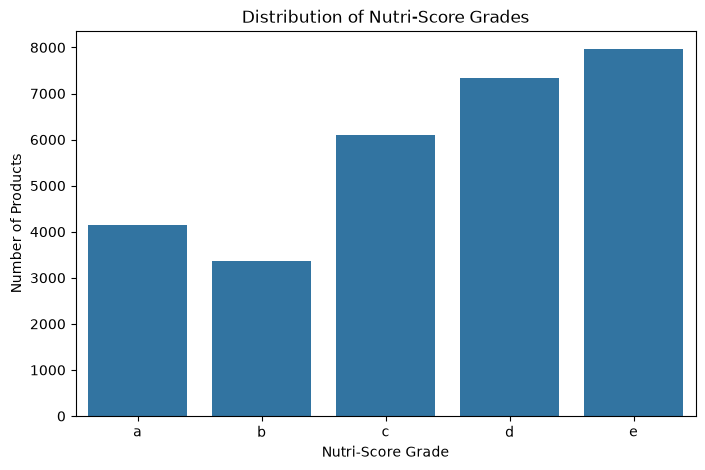

nutriscore_grade
a    14.35
b    11.64
c    21.12
d    25.37
e    27.51
Name: proportion, dtype: float64

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_model_nutri, x="nutriscore_grade", order=["a", "b", "c", "d", "e"])
plt.title("Distribution of Nutri-Score Grades")
plt.xlabel("Nutri-Score Grade")
plt.ylabel("Number of Products")
plt.show()

df_model_nutri["nutriscore_grade"].value_counts(normalize=True).sort_index().round(4) * 100


A count plot is used to visualize the absolute frequency of each Nutri-Score class and to assess the degree of class imbalance before model training.

The cleaned Nutri-Score dataset contains 28,924 products and shows a moderate imbalance toward the less favorable grades. Grade E is the most frequent class, representing 27.51% of observations, followed by grade D with 25.37% and grade C with 21.12%. Grades A and B are less common, accounting for 14.35% and 11.64% of the dataset, respectively.

Because the class distribution is not uniform, model performance should not be assessed through accuracy alone. Class-sensitive evaluation metrics, including the F1-score, are therefore considered in the later model comparison.

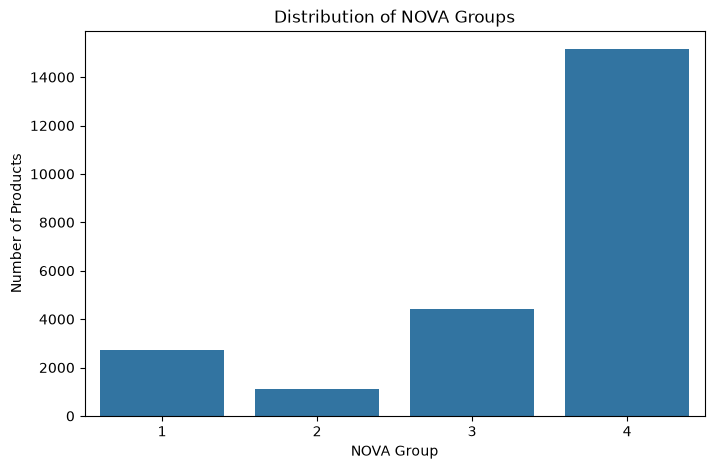

nova_group_clean
1    11.69
2     4.78
3    18.81
4    64.73
Name: proportion, dtype: float64

In [20]:
# distribution of the NOVA group
# Cast to int so seaborn categories match order=[1, 2, 3, 4]
df_model_nova_plot = df_model_nova.copy()
df_model_nova_plot["nova_group_clean"] = df_model_nova_plot["nova_group_clean"].astype(int)

plt.figure(figsize=(8, 5))
sns.countplot(data=df_model_nova_plot, x="nova_group_clean", order=[1, 2, 3, 4])
plt.title("Distribution of NOVA Groups")
plt.xlabel("NOVA Group")
plt.ylabel("Number of Products")
plt.show()

df_model_nova_plot["nova_group_clean"].value_counts(normalize=True).sort_index().round(4) * 100


The NOVA modeling dataset contains 23,406 products and exhibits a pronounced class imbalance. NOVA group 4 (ultra-processed foods) is by far the largest class, accounting for 64.73% of all observations. Groups 3 and 1 represent 18.81% and 11.69% of the dataset, respectively, while group 2 is the smallest class with only 4.78% of products.

This distribution is consistent with previous research showing that packaged food databases are dominated by ultra-processed products, whereas processed culinary ingredients (group 2) constitute only a small proportion of retail food products (Monteiro et al., 2019). Consequently, class imbalance should be considered during model training and evaluation, making class-sensitive performance metrics such as the F1-score particularly important.

### 9.2 Summary Statistics of Nutritional Features

Summary statistics provide an overview of the numerical nutritional variables. They show the average values, standard deviations, and ranges of the selected features.

In [21]:
df_model_nova[nutrient_features].describe().round(2)


,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
count,21299.00,21286.00,20176.00,21279.00,20795.00,16004.00,21281.00,20822.00,20823.00
mean,277.77,14.34,5.20,29.62,14.07,2.90,7.56,1.25,0.50
std,199.67,19.58,8.22,27.96,19.96,4.91,8.94,4.90,1.96
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,100.00,0.60,0.10,4.67,0.90,0.00,1.00,0.04,0.02
50%,262.00,6.90,1.89,18.00,4.20,1.43,5.30,0.45,0.18
75%,405.00,21.43,7.30,54.00,20.00,3.60,10.34,1.22,0.49
max,1000.00,100.00,100.00,100.00,100.00,100.00,95.00,100.00,40.00


The descriptive statistics indicate substantial variation in the nutritional composition of the products. Carbohydrates show the highest median content (18.0 g per 100 g), followed by fat (6.9 g) and proteins (5.3 g). Fiber has the lowest median value (1.43 g per 100 g), reflecting that many processed products contain little or no dietary fiber.

Several nutrient variables exhibit pronounced right-skewed distributions, as indicated by means that exceed the corresponding medians, particularly for fat, saturated fat, sugars, salt, and fiber. This suggests that while most products contain relatively moderate nutrient levels, a smaller number of products with very high values increase the overall averages. The applied plausibility filters ensure that all remaining observations fall within physically realistic ranges, while preserving the natural variability of the dataset for the subsequent analyses.

### 9.3 Average Nutritional Values by Nutri-Score Grade / NOVA Group

After inspecting the overall summary statistics, the next step is to compare the average nutritional values across classes. This helps identify whether products with less favorable classes show higher average levels of nutrients such as energy, fat, saturated fat, sugar, or salt.

                  energy-kcal_100g  fat_100g  saturated-fat_100g  \
nutriscore_grade                                                   
a                           172.47      5.26                0.82   
b                           215.00     14.47                2.29   
c                           201.00      9.65                2.43   
d                           304.94     16.33                6.27   
e                           385.23     21.38               10.17   

                  carbohydrates_100g  sugars_100g  fiber_100g  proteins_100g  \
nutriscore_grade                                                               
a                              20.04         2.72        4.45          10.59   
b                              14.88         2.53        1.91           5.84   
c                              21.27         6.37        2.85           6.54   
d                              28.70        12.55        2.79          10.24   
e                              39.96       

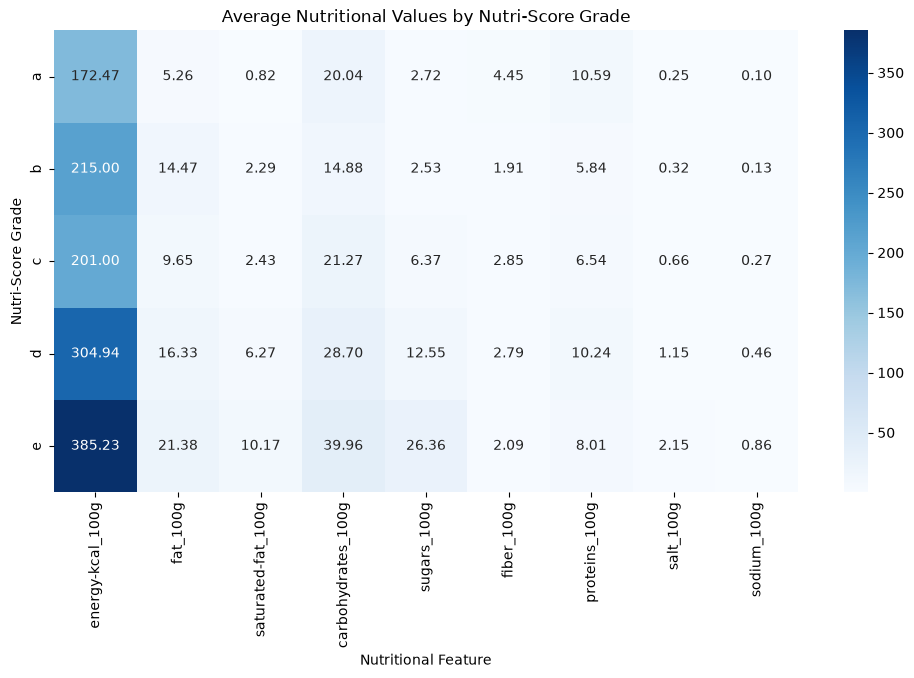

In [22]:
grade_means = df_model_nutri.groupby("nutriscore_grade")[nutrient_features].mean().round(2)
print(grade_means)

plt.figure(figsize=(12, 6))
sns.heatmap(grade_means, annot=True, fmt=".2f", cmap="Blues")
plt.title("Average Nutritional Values by Nutri-Score Grade")
plt.xlabel("Nutritional Feature")
plt.ylabel("Nutri-Score Grade")
plt.show()


The average nutrient profiles differ systematically across Nutri-Score grades. Products with less favorable grades generally contain higher amounts of energy, fat, saturated fat, sugars, salt, and sodium than products with more favorable grades. For example, average energy increases from 172.47 kcal per 100 g for grade A products to 385.23 kcal for grade E products, while average sugar content rises from 2.72 g to 26.36 g and average salt content from 0.25 g to 2.15 g per 100 g.

In contrast, fiber and protein do not exhibit a strictly monotonic relationship with Nutri-Score. Their average values vary across grades because these nutrients are influenced not only by the Nutri-Score algorithm but also by differences in product composition across food categories. Overall, the observed nutrient patterns are consistent with the construction of the Nutri-Score algorithm, which assigns less favorable grades to products with higher levels of unfavorable nutrients while rewarding beneficial components such as fiber and protein (van der Bend et al., 2022; Merz et al., 2024).

                  energy-kcal_100g  fat_100g  saturated-fat_100g  \
nova_group_clean                                                   
1.0                         197.00      6.90                1.50   
2.0                         605.55     58.41               14.94   
3.0                         260.94     14.37                5.13   
4.0                         273.13     12.47                5.11   

                  carbohydrates_100g  sugars_100g  fiber_100g  proteins_100g  \
nova_group_clean                                                               
1.0                            25.35         6.35        4.67           7.86   
2.0                            22.79        19.14        0.80           0.83   
3.0                            22.40         7.54        3.03           9.77   
4.0                            33.05        17.01        2.56           7.33   

                  salt_100g  sodium_100g  additives_n  ingredients_n  
nova_group_clean                       

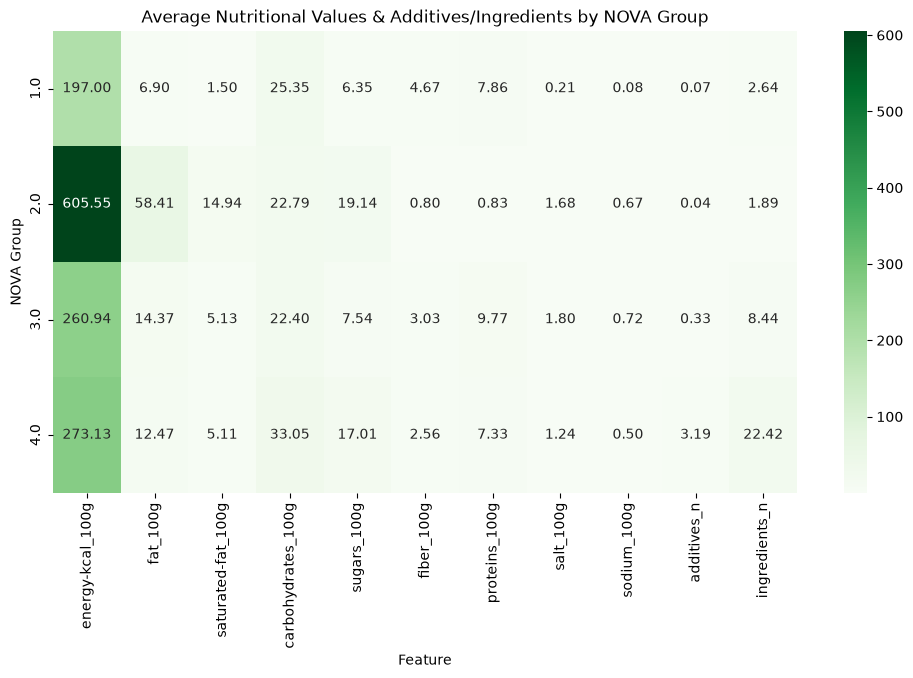

In [23]:
# average nutrient + additive/ingredient values by NOVA group
nova_means = df_model_nova.groupby("nova_group_clean")[extended_numeric_features].mean().round(2)
print(nova_means)

plt.figure(figsize=(12, 6))
sns.heatmap(nova_means, annot=True, fmt=".2f", cmap="Greens")
plt.title("Average Nutritional Values & Additives/Ingredients by NOVA Group")
plt.xlabel("Feature")
plt.ylabel("NOVA Group")
plt.show()


The average feature profiles differ clearly across NOVA groups. Group 1 products show comparatively low values for energy, fat, saturated fat, salt, additives, and ingredients, which is consistent with minimally processed foods. Group 2 stands out through very high average energy and fat values, reflecting that this category mainly includes processed culinary ingredients such as oils, fats, sugar, and salt.

Group 3 products contain more ingredients and additives than groups 1 and 2, but substantially fewer than group 4. Ultra-processed products in group 4 have by far the highest average number of additives and ingredients, with 3.19 additives and 22.42 ingredients per product. They also show comparatively high values for carbohydrates and sugars. This pattern is consistent with the NOVA framework, which characterizes ultra-processed foods as industrial formulations made from numerous ingredients and commonly containing cosmetic additives (Monteiro et al., 2019).

Overall, `additives_n` and `ingredients_n` appear particularly relevant for distinguishing NOVA group 4, while the nutrient variables help differentiate the broader processing profiles of the remaining groups.

### 9.4 Correlation Analysis

A correlation analysis is used to examine relationships between the numerical nutritional features. This helps identify variables that are strongly related to each other, such as salt and sodium or fat and saturated fat. Understanding correlations is useful before machine learning because highly correlated features may contain overlapping information. This can be especially relevant for models such as Logistic Regression or K-Nearest Neighbors.

                    energy-kcal_100g  fat_100g  saturated-fat_100g  \
energy-kcal_100g                1.00      0.82                0.59   
fat_100g                        0.82      1.00                0.68   
saturated-fat_100g              0.59      0.68                1.00   
carbohydrates_100g              0.41     -0.13               -0.06   
sugars_100g                     0.26     -0.08                0.07   
fiber_100g                      0.23      0.06               -0.01   
proteins_100g                   0.20      0.10                0.10   
salt_100g                      -0.06     -0.04               -0.03   
sodium_100g                    -0.06     -0.04               -0.03   

                    carbohydrates_100g  sugars_100g  fiber_100g  \
energy-kcal_100g                  0.41         0.26        0.23   
fat_100g                         -0.13        -0.08        0.06   
saturated-fat_100g               -0.06         0.07       -0.01   
carbohydrates_100g             

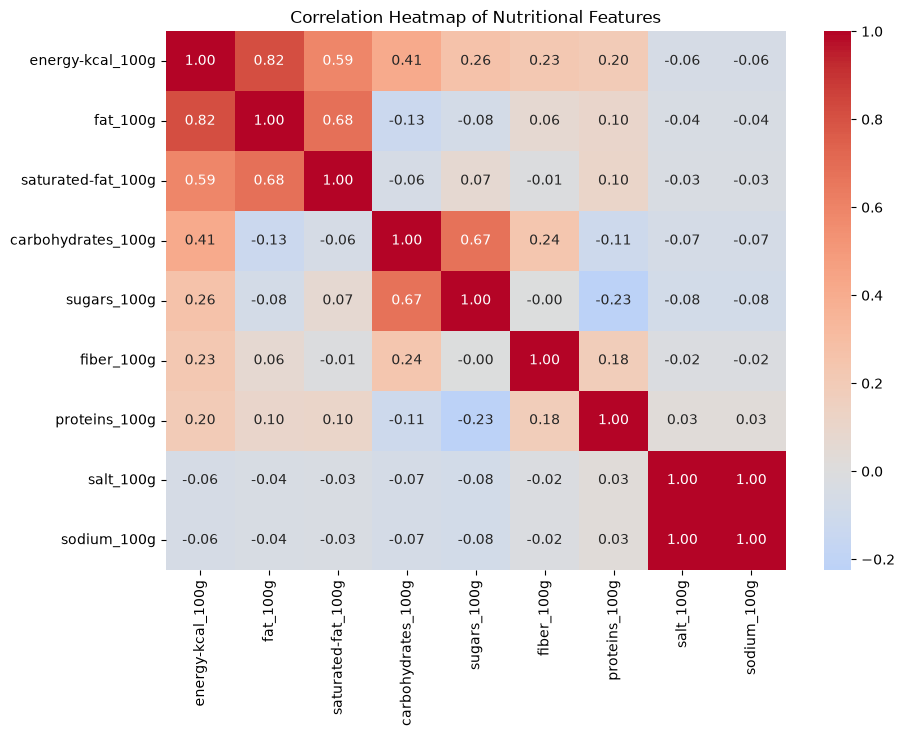

In [24]:
correlation_matrix = df_model_nova[nutrient_features].corr()
print(correlation_matrix.round(2))

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Nutritional Features")    
plt.show()


The correlation analysis reveals several expected relationships between the nutritional features. Energy is strongly positively correlated with fat (`r = 0.82`) and moderately correlated with saturated fat (`r = 0.59`), reflecting the high energy density of dietary fat. Fat and saturated fat are also strongly related (`r = 0.68`), while carbohydrates and sugars show a similarly strong positive correlation (`r = 0.67`) because sugars form part of total carbohydrates (Bauer et al., 2013; Reynolds et al., 2019; Snetselaar et al., 2021; van der Bend et al., 2022; Merz et al., 2024; World Health Organization, 2026).

The strongest relationship occurs between salt and sodium, which are perfectly correlated after rounding (`r = 1.00`). This is expected because salt content is derived from sodium using an approximately fixed conversion factor (European Commission, 2026). Including both variables therefore introduces substantial redundancy. This is particularly relevant for linear models, which can be more sensitive to multicollinearity, whereas tree-based models are generally less affected by highly correlated predictors. Salt and sodium should therefore not both be used in analyses where redundant features could distort the results, such as the nutrient-based clustering in Section 11.

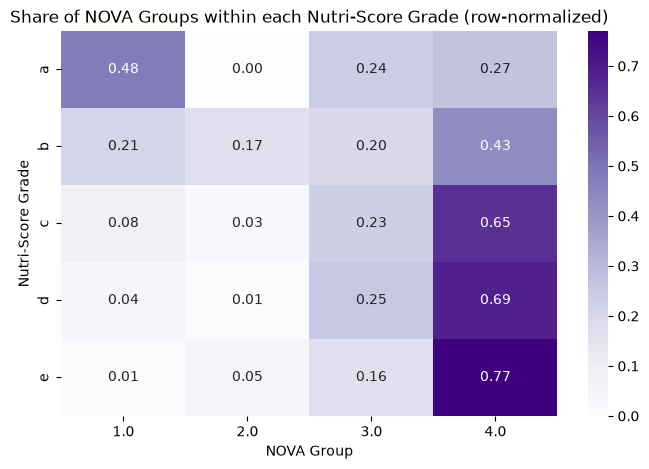

Number of products with BOTH valid target variables: 17787


nova_group_clean,1.0,2.0,3.0,4.0
nutriscore_grade,,,,
a,0.48,0.00,0.24,0.27
b,0.21,0.17,0.20,0.43
c,0.08,0.03,0.23,0.65
d,0.04,0.01,0.25,0.69
e,0.01,0.05,0.16,0.77


In [25]:
# cross-tabulation Nutri-Score x NOVA group
# Tests Hypothesis H3: are Nutri-Score and NOVA group independent dimensions,
# or does a good Nutri-Score automatically imply a low (good) NOVA group?
merged_targets = df_features_clean[
    df_features_clean["nutriscore_grade"].isin(valid_grades)
    & df_features_clean["nova_group_clean"].isin([1, 2, 3, 4])
][["nutriscore_grade", "nova_group_clean"]].copy()

crosstab_norm = pd.crosstab(
    merged_targets["nutriscore_grade"],
    merged_targets["nova_group_clean"],
    normalize="index"
).round(2)

plt.figure(figsize=(8, 5))
sns.heatmap(crosstab_norm, annot=True, fmt=".2f", cmap="Purples")
plt.title("Share of NOVA Groups within each Nutri-Score Grade (row-normalized)")
plt.xlabel("NOVA Group")
plt.ylabel("Nutri-Score Grade")
plt.show()

print(f"Number of products with BOTH valid target variables: {len(merged_targets)}")
crosstab_norm


The cross-tabulation is based on 17,787 products with valid labels for both classification systems and shows a clear relationship between Nutri-Score and NOVA group. Among products with Nutri-Score A, 48% belong to NOVA group 1, while 27% are classified as ultra-processed foods in NOVA group 4. The proportion of NOVA group 4 products increases across the less favorable Nutri-Score grades, reaching 43% for grade B, 65% for grade C, 69% for grade D, and 77% for grade E.

These results are consistent with previous research using Open Food Facts data. Romero Ferreiro et al. (2021) similarly found that ultra-processed foods accounted for 26.1% of Nutri-Score A products and 83.7% of Nutri-Score E products, while Sarda et al. (2024) also reported an increasing prevalence of NOVA group 4 across less favorable Nutri-Score grades.

The observed pattern indicates that nutritional quality and degree of processing are related but not interchangeable. Less favorable Nutri-Score grades are more frequently associated with ultra-processed products, yet a substantial proportion of nutritionally favorable products are also classified as ultra-processed. Nutri-Score and NOVA therefore capture complementary dimensions of food products: nutritional composition and degree of industrial processing.

## 10. Preprocessing for Machine Learning

Before training the machine learning models, the cleaned datasets are prepared using standardized preprocessing pipelines. The preprocessing consists of three main steps: splitting the data into training and test sets, handling missing values, and transforming the predictor variables into a format suitable for model training.

The data are first divided into training and test sets using a stratified train-test split to preserve the class distribution of the target variable in both subsets. This ensures that minority classes remain proportionally represented during model evaluation.

All subsequent preprocessing steps are implemented within a scikit-learn `Pipeline` and `ColumnTransformer`. Numerical features are imputed using the median of the training data and subsequently standardized using `StandardScaler`. Performing these operations within the pipeline ensures that all preprocessing parameters are estimated exclusively from the training set before being applied to the test set, thereby preventing information leakage.

Separate preprocessing pipelines are constructed for the NOVA and Nutri-Score prediction tasks. Both follow the same methodology, differing only in the respective target variable used for model training.

In [26]:
# Features (X) and target (y) for the NOVA main problem
numeric_cols = extended_numeric_features
categorical_cols = ["main_category_grouped"]

X = df_model_nova[numeric_cols + categorical_cols]
y = df_model_nova["nova_group_clean"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nClass distribution (train):\n", y_train.value_counts(normalize=True).round(2))
print("\nClass distribution (test):\n", y_test.value_counts(normalize=True).round(2))


Train shape: (18724, 12)  Test shape: (4682, 12)

Class distribution (train):
 nova_group_clean
4    0.65
3    0.19
1    0.12
2    0.05
Name: proportion, dtype: float64

Class distribution (test):
 nova_group_clean
4    0.65
3    0.19
1    0.12
2    0.05
Name: proportion, dtype: float64


The stratified train-test split produces 18,724 training observations and 4,682 test observations. The class proportions are identical across both subsets, with NOVA group 4 representing 65% of products, group 3 representing 19%, group 1 representing 12%, and group 2 representing 5%.

This confirms that stratification successfully preserves the original class distribution. As a result, the test set provides a representative basis for evaluating model performance across all four NOVA classes.

In [27]:
# ColumnTransformer: numeric features -> median imputation + scaling
#                      categorical features -> one-hot encoding
# Fit with .fit_transform() ONLY on X_train (inside each pipeline below),
# and applied with .transform() to X_test -- no leakage.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)


The preprocessing object is defined in this step but is not fitted directly. Instead, it is included within each machine learning pipeline and fitted only when the corresponding model is trained on `X_train`. This ensures that median imputation, standardization, and one-hot encoding are learned exclusively from the training data and then applied consistently to the test data.

## 11. Clustering (Unsupervised Learning)

### 11.1 Purpose of the Clustering Analysis

The supervised analyses in the later sections predict predefined NOVA and Nutri-Score labels. In contrast, clustering is used here as an exploratory unsupervised method to examine whether products form naturally occurring groups based only on their nutrient profiles.

KMeans clustering partitions observations into a predefined number of clusters by minimizing the within-cluster distance between observations and their assigned cluster centers (MacQueen, 1967). Similar clustering approaches have been used in nutritional research to identify dietary or food-related patterns in multidimensional data (O'Hara et al., 2022).

This analysis is directly linked to Hypothesis H4. Nutri-Score is largely determined by nutritional composition, whereas NOVA primarily reflects the degree and purpose of food processing (Monteiro et al., 2016; Romero Ferreiro et al., 2021; Merz et al., 2024; Sarda et al., 2024). Therefore, nutrient-based clusters are expected to align more closely with Nutri-Score than with NOVA.

Only nutrient variables are used for clustering. Additive counts, ingredient counts, and product-category information are excluded because they are more closely related to NOVA classification and would weaken the nutrient-only comparison underlying H4. The resulting clusters should be interpreted as exploratory nutrient profiles rather than official nutritional or processing categories.

### 11.2 Preparation of the Clustering Dataset

The clustering sample contains only products with both a valid Nutri-Score grade and a valid NOVA group. This ensures that the same observations can later be compared with both classification systems.

Before clustering, missing nutrient values are replaced with the median of the corresponding feature. The variables are then standardized using `StandardScaler`. Standardization is important for distance-based clustering because variables measured on larger numerical scales would otherwise have disproportionate influence on the calculated distances (Milligan & Cooper, 1988).

Salt and sodium measure closely related aspects of the same nutritional dimension. Their correlation is therefore examined before the final clustering features are selected.

In [28]:
# Create a common sample with valid labels for both comparison systems

cluster_source = df_features_clean[
    df_features_clean["nutriscore_grade"].isin(valid_grades)
    & df_features_clean["nova_group_clean"].isin([1, 2, 3, 4])
].copy()

print("Products available for clustering:", len(cluster_source))


Products available for clustering: 17787


A total of 17,787 products contain complete information for all variables required for the clustering analysis. This subset corresponds to the products for which both Nutri-Score and NOVA labels are available, enabling the resulting clusters to be compared directly with both classification systems in the subsequent analysis.

In [29]:
# Examine the relationship between salt and sodium before selecting the final clustering features

salt_sodium_corr = cluster_source[
    ["salt_100g", "sodium_100g"]
].corr()

display(salt_sodium_corr)

salt_sodium_r = salt_sodium_corr.loc["salt_100g", "sodium_100g"]

print(
    "Correlation between salt_100g and sodium_100g:",
    round(salt_sodium_r, 3)
)


,salt_100g,sodium_100g
salt_100g,1.00000,0.99989
sodium_100g,0.99989,1.00000


Correlation between salt_100g and sodium_100g: 1.0


In [30]:
# Final nutrient-only feature set for clustering; Sodium is excluded because it strongly overlaps with salt.

cluster_features = [
    "energy-kcal_100g",
    "fat_100g",
    "saturated-fat_100g",
    "carbohydrates_100g",
    "sugars_100g",
    "fiber_100g",
    "proteins_100g",
    "salt_100g",
]

# Median imputation and standardization
cluster_imputer = SimpleImputer(strategy="median")
cluster_scaler = StandardScaler()

X_cluster_imputed = cluster_imputer.fit_transform(
    cluster_source[cluster_features]
)

X_cluster_scaled = cluster_scaler.fit_transform(
    X_cluster_imputed
)

print("Clustering dataset:", X_cluster_scaled.shape)
print("Number of clustering features:", len(cluster_features))


Clustering dataset: (17787, 8)
Number of clustering features: 8


The clustering dataset contains 17,787 products and eight nutrient features. Although both `salt_100g` and `sodium_100g` were initially available, their correlation is nearly perfect (`r = 0.99989`), indicating that they contain almost identical information. Including both variables would give the salt-related dimension disproportionate influence in the distance calculations.

Therefore, `sodium_100g` is excluded while `salt_100g` is retained, resulting in a final clustering feature set of eight nutrient variables.

### 11.3 Selection of the Number of Clusters

KMeans requires the number of clusters, \(k\), to be specified in advance. Two complementary criteria are therefore examined for values from \(k=2\) to \(k=12\).

The elbow method evaluates how strongly within-cluster inertia decreases as additional clusters are introduced. A visible flattening of the curve suggests that further clusters provide diminishing improvements. The silhouette score evaluates both cluster cohesion and separation, with higher values indicating a more clearly separated clustering solution (Rousseeuw, 1987).

The final value of \(k\) is selected primarily based on the highest silhouette score, while the elbow curve provides supporting descriptive evidence.

In [31]:
# Evaluate alternative numbers of clusters using inertia and silhouette score

inertia_values = []
silhouette_values = []
k_range = range(2, 13)

for k in k_range:
    kmeans_candidate = KMeans(
        n_clusters=k,
        random_state=SEED,
        n_init=10
    )

    candidate_labels = kmeans_candidate.fit_predict(
        X_cluster_scaled
    )

    inertia_values.append(kmeans_candidate.inertia_)
    silhouette_values.append(
        silhouette_score(
            X_cluster_scaled,
            candidate_labels
        )
    )

cluster_evaluation = pd.DataFrame({
    "k": list(k_range),
    "inertia": inertia_values,
    "silhouette_score": silhouette_values,
})

display(cluster_evaluation.round(4))


,k,inertia,silhouette_score
0,2,110529.9477,0.3163
1,3,89139.3854,0.3507
2,4,76619.1584,0.3564
3,5,65788.0647,0.3536
4,6,55687.1910,0.3706
5,7,49599.1681,0.3622
6,8,44514.9570,0.3772
7,9,40469.1849,0.3857
8,10,37280.2467,0.3577
9,11,34647.6826,0.3575


The silhouette score is highest for \(k = 9\) at 0.3857. Inertia decreases continuously as \(k\) increases, but the reductions become progressively smaller. These results identify \(k = 9\) as the strongest candidate for the final cluster solution, which is evaluated together with the elbow plot below.

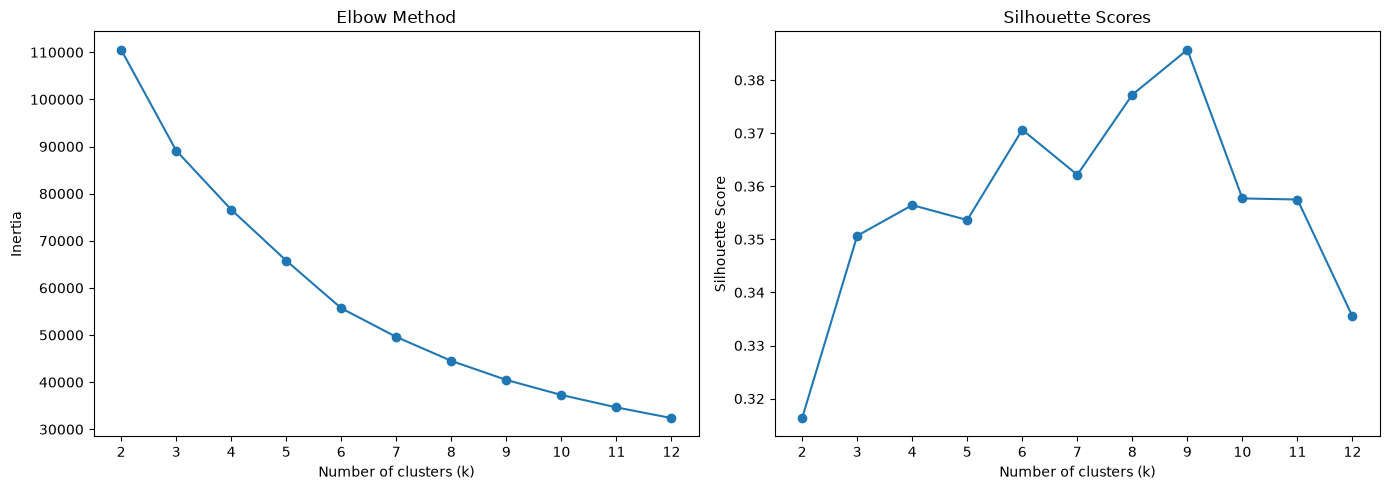

In [32]:
# Visualize the elbow and silhouette results

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    cluster_evaluation["k"],
    cluster_evaluation["inertia"],
    marker="o"
)
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(list(k_range))

axes[1].plot(
    cluster_evaluation["k"],
    cluster_evaluation["silhouette_score"],
    marker="o"
)
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()


The elbow method indicates that the reduction in within-cluster variance becomes progressively smaller as the number of clusters increases, with the curve beginning to flatten after approximately six to eight clusters. The silhouette analysis reaches its highest value at \(k = 9\), suggesting that this solution provides the strongest separation between clusters. Because the elbow curve also shows diminishing improvements beyond this range, \(k = 9\) is selected for the subsequent clustering analysis. This choice balances statistical cluster quality with an interpretable cluster solution.

### 11.4 Final KMeans Clustering

The final KMeans model is fitted using the value of \(k\) with the highest silhouette score. A fixed random seed improves reproducibility, while `n_init=10` evaluates multiple initial cluster-center configurations and retains the solution with the lowest inertia.

The resulting cluster labels are arbitrary identifiers without an ordinal interpretation. A higher cluster number does not indicate a nutritionally better, worse, or more highly processed group.

In [33]:
# Select the value of k with the highest silhouette score

best_k = int(
    cluster_evaluation.loc[
        cluster_evaluation["silhouette_score"].idxmax(),
        "k"
    ]
)

best_silhouette = float(
    cluster_evaluation["silhouette_score"].max()
)

print("Chosen k:", best_k)
print("Best silhouette score:", round(best_silhouette, 4))


Chosen k: 9
Best silhouette score: 0.3857


Based on the combined evaluation of the elbow method and silhouette analysis, a final solution of \(k = 9\) clusters is selected. This solution achieves the highest silhouette score (0.3857), indicating the best balance between cluster cohesion and separation among the evaluated values of \(k\). The selected cluster solution is used for all subsequent analyses and comparisons with the Nutri-Score and NOVA classification systems.

In [34]:
# Fit the final KMeans model and assign cluster labels

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=SEED,
    n_init=10
)

cluster_source["cluster"] = kmeans_final.fit_predict(
    X_cluster_scaled
)

cluster_sizes = (
    cluster_source["cluster"]
    .value_counts()
    .sort_index()
    .rename("number_of_products")
    .to_frame()
)

cluster_sizes["share"] = (
    cluster_sizes["number_of_products"]
    / cluster_sizes["number_of_products"].sum()
)

display(cluster_sizes.round(4))


,number_of_products,share
cluster,,
0,7257,0.4080
1,2899,0.1630
2,2031,0.1142
3,697,0.0392
4,2566,0.1443
5,42,0.0024
6,135,0.0076
7,791,0.0445
8,1369,0.0770


The selected \(k = 9\) solution produces clusters of markedly different sizes. Cluster 0 is the largest, containing 7,257 products (40.8% of the dataset), followed by clusters 1 (16.3%), 4 (14.4%), and 2 (11.4%). The remaining clusters are considerably smaller, with clusters 5 and 6 accounting for less than 1% of all products.

The unequal cluster sizes suggest that the nutritional profiles are not evenly distributed across the dataset. While a few broad dietary patterns describe a large proportion of products, several smaller clusters capture more specialized nutrient compositions. These smaller clusters may therefore represent distinctive product types that would not be identified using a smaller number of clusters.

### 11.5 Visualization of the Clustering Solution

Principal Component Analysis (PCA) is used to visualize the clustering solution in two dimensions. PCA creates new components that successively capture large proportions of the variation in the original variables (Jolliffe & Cadima, 2016).

PCA is used only for visualization in this notebook. The KMeans model itself is fitted on the complete set of eight standardized nutrient features. The two-dimensional figure is therefore a simplified projection rather than a complete representation of the clustering space.

The share of variance explained by the first two principal components is reported to indicate how much of the original nutrient variation is represented in the visualization.

In [35]:
# Reduce the standardized nutrient space to two dimensions for visualization

pca = PCA(
    n_components=2,
    random_state=SEED
)

X_pca = pca.fit_transform(
    X_cluster_scaled
)

explained_variance_2d = (
    pca.explained_variance_ratio_.sum()
)

print(
    "Explained variance by the first two PCA components:",
    f"{explained_variance_2d:.2%}"
)


Explained variance by the first two PCA components: 54.66%


The first two principal components explain 54.66% of the total variance in the eight-dimensional nutrient feature space. Although nearly half of the variation remains in the higher principal components, the two-dimensional PCA projection provides a useful visualization of the overall cluster structure while preserving the dominant patterns in the data.

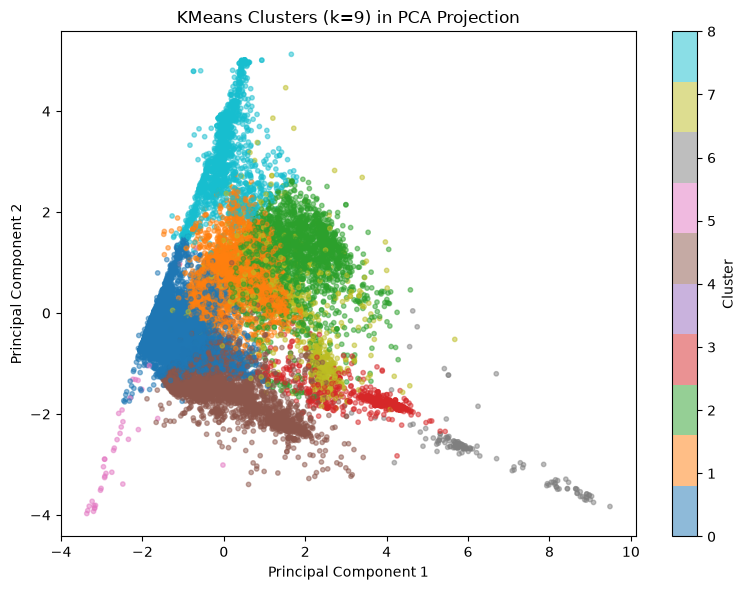

In [36]:
# Visualize the final KMeans solution in the PCA projection

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_source["cluster"],
    cmap="tab10",
    alpha=0.5,
    s=10
)

plt.title(
    f"KMeans Clusters (k={best_k}) in PCA Projection"
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster")

plt.tight_layout()
plt.show()


The PCA projection illustrates the nine K-means clusters in two dimensions. Several clusters form distinct regions, whereas others partially overlap, indicating that some nutrient profiles are clearly separable while others transition more gradually. This is expected because food products vary continuously in their nutritional composition rather than forming completely discrete groups (Bauer et al., 2013; van der Bend et al., 2022; Merz et al., 2024).

The visualization also shows that a small number of clusters occupy more isolated regions of the feature space, whereas the largest clusters cover broader and denser areas. Overall, the PCA projection supports the selected clustering solution by demonstrating that meaningful structure is present in the nutrient data, while also highlighting the inherent overlap between nutritional profiles.

### 11.6 Interpretation of Nutrient-Based Cluster Profiles

The numerical cluster labels do not have substantive meaning by themselves. To interpret the groups, the average nutrient values per 100 g are calculated for each cluster.

Because nutrients differ substantially in their numerical units and ranges, an additional relative profile is calculated by dividing each cluster mean by the overall mean of the corresponding nutrient. A value above 1 indicates that a cluster contains more of that nutrient than the overall clustering sample on average, while a value below 1 indicates a lower-than-average value.


In [37]:
# Mean nutrient values for each cluster in the original measurement units

cluster_profiles = (
    cluster_source
    .groupby("cluster")[cluster_features]
    .mean()
    .round(2)
)

display(cluster_profiles)


,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g
cluster,,,,,,,,
0,101.79,4.41,1.54,11.69,6.31,1.36,3.19,0.76
1,378.12,11.35,2.33,60.08,8.10,4.32,8.66,1.15
2,483.70,27.69,14.14,52.46,35.96,2.86,6.28,0.45
3,756.50,82.91,13.26,1.97,0.86,0.84,1.65,0.47
4,270.82,18.72,8.39,4.91,1.70,0.57,20.79,1.88
5,65.08,1.08,0.79,10.09,9.44,1.26,1.42,66.35
6,766.75,84.78,62.96,2.28,1.53,1.37,0.92,0.36
7,477.55,29.93,5.93,34.21,8.69,13.83,17.91,0.91
8,329.41,2.60,1.21,75.12,61.21,1.59,1.92,0.34


The table reports the mean nutrient values of each cluster in the original measurement units. This allows the nutritional profiles identified by K-means to be interpreted directly in terms of kilocalories and grams per 100 g of product.

The clusters differ substantially in their average compositions. Cluster 0 represents relatively low-energy products with low fat and carbohydrate contents, while cluster 3 is characterized by very high energy and fat levels. Cluster 8 contains products with particularly high carbohydrate and sugar contents, whereas cluster 4 has the highest average protein content. Cluster 7 combines relatively high protein and fiber values.

Some clusters capture highly specialized nutrient profiles. Cluster 5 is dominated by products with extremely high salt content, and cluster 6 by products with very high saturated fat levels. These profiles suggest that the clustering solution separates broad nutritional patterns as well as smaller groups of compositionally distinctive products.

In [38]:
# Relative nutrient profiles compared with the overall clustering sample

overall_nutrient_means = (
    cluster_source[cluster_features]
    .mean()
)

cluster_relative_profiles = (
    cluster_source
    .groupby("cluster")[cluster_features]
    .mean()
    .div(overall_nutrient_means)
)

display(cluster_relative_profiles.round(2))


,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g
cluster,,,,,,,,
0,0.36,0.29,0.29,0.40,0.46,0.50,0.43,0.71
1,1.34,0.75,0.43,2.08,0.60,1.59,1.16,1.08
2,1.72,1.84,2.64,1.82,2.65,1.05,0.84,0.42
3,2.68,5.50,2.47,0.07,0.06,0.31,0.22,0.44
4,0.96,1.24,1.57,0.17,0.13,0.21,2.77,1.76
5,0.23,0.07,0.15,0.35,0.70,0.46,0.19,62.02
6,2.72,5.63,11.75,0.08,0.11,0.50,0.12,0.34
7,1.69,1.99,1.11,1.18,0.64,5.08,2.39,0.85
8,1.17,0.17,0.23,2.60,4.51,0.59,0.26,0.32


The relative profiles compare each cluster’s mean nutrient values with the overall mean of the clustering sample. A value above 1 indicates that the cluster contains more of the respective nutrient than the sample average, while a value below 1 indicates a lower-than-average level.

The results make the distinctive cluster characteristics more visible. Cluster 3 contains around 5.5 times the average fat content, while cluster 6 combines approximately 5.6 times the average fat content with almost 11.8 times the average saturated fat content. Cluster 5 is dominated by salt, with an average level around 62 times higher than the overall sample mean. Cluster 8 shows particularly high relative values for carbohydrates and sugars, whereas cluster 7 is characterized by substantially elevated fiber and protein levels. Cluster 4 also stands out through comparatively high protein and salt values.

These relative profiles complement the original-unit cluster means by showing which nutrients most strongly differentiate each cluster from the overall product sample.

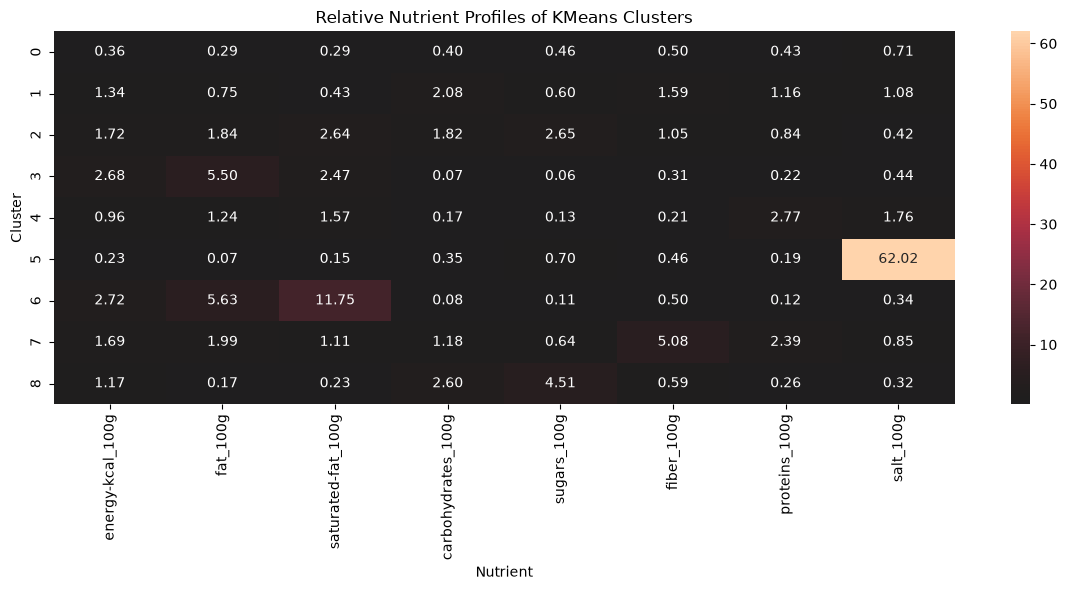

In [39]:
# Heatmap of relative nutrient profiles

plt.figure(figsize=(12, 6))

sns.heatmap(
    cluster_relative_profiles,
    annot=True,
    fmt=".2f",
    center=1
)

plt.title(
    "Relative Nutrient Profiles of KMeans Clusters"
)
plt.xlabel("Nutrient")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()


The heatmap provides a visual summary of how strongly each cluster differs from the overall nutrient profile of the clustering sample. Values above 1 indicate above-average nutrient levels, whereas values below 1 indicate below-average levels.

The visualization highlights several highly distinctive profiles. Cluster 5 is almost entirely characterized by exceptionally high salt content, while cluster 6 shows extreme relative values for fat and especially saturated fat. Cluster 3 is also dominated by fat, whereas cluster 8 is clearly associated with high carbohydrate and sugar levels. Cluster 7 stands out through elevated fiber and protein values, and cluster 4 through comparatively high protein and salt levels.

Overall, the heatmap confirms that the nine-cluster solution captures both broad nutrient patterns and a small number of highly specialized product profiles. Because extreme values such as the salt level in cluster 5 dominate the color scale, the numerical annotations remain important for interpreting differences among the remaining clusters.

### 11.7 Comparison with Nutri-Score and NOVA

The Adjusted Rand Index (ARI) is used to quantify the agreement between the nutrient-based clusters and the two external classification systems. The ARI corrects for agreement that could occur by chance and is suitable for comparing two alternative partitions of the same observations (Hubert & Arabie, 1985).

An ARI close to 1 indicates strong agreement, while values around 0 indicate agreement close to chance. Hypothesis H4 predicts that the ARI between the nutrient clusters and Nutri-Score will be higher than the ARI between the nutrient clusters and NOVA.


In [40]:
# Compare cluster membership with Nutri-Score and NOVA

ari_nutriscore = adjusted_rand_score(
    cluster_source["nutriscore_grade"],
    cluster_source["cluster"]
)

ari_nova = adjusted_rand_score(
    cluster_source["nova_group_clean"],
    cluster_source["cluster"]
)

ari_comparison = pd.DataFrame({
    "comparison": [
        "Clusters vs. Nutri-Score",
        "Clusters vs. NOVA"
    ],
    "adjusted_rand_index": [
        ari_nutriscore,
        ari_nova
    ]
})

display(ari_comparison.round(4))

if ari_nutriscore > ari_nova:
    print(
        "The nutrient clusters align more closely with Nutri-Score than with NOVA."
    )
elif ari_nutriscore < ari_nova:
    print(
        "The nutrient clusters align more closely with NOVA than with Nutri-Score."
    )
else:
    print(
        "The two ARI values are equal."
    )


,comparison,adjusted_rand_index
0,Clusters vs. Nutri-Score,0.0805
1,Clusters vs. NOVA,0.0290


The nutrient clusters align more closely with Nutri-Score than with NOVA.


The Adjusted Rand Index (ARI) quantifies the agreement between the nutrient-based clusters and the two existing food classification systems. The clusters show a stronger correspondence with Nutri-Score (ARI = 0.0805) than with NOVA (ARI = 0.0290), although both values indicate only weak overall agreement.

These results suggest that nutrient-based clustering captures patterns that are more closely related to nutritional composition than to the degree of food processing. This finding is consistent with the construction of the clustering algorithm, which relies exclusively on nutrient variables. In contrast, the NOVA system additionally considers characteristics such as processing methods, ingredient formulations, and the use of additives, which are not included in the clustering features (Monteiro et al., 2019).

Consequently, the clustering analysis supports the hypothesis that nutrient-based groupings resemble Nutri-Score more closely than NOVA, while also demonstrating that the clusters represent a distinct nutritional structure rather than reproducing either classification system exactly.

### 11.8 Distribution of Nutri-Score and NOVA within Clusters

The ARI provides a single overall measure of agreement, but it does not show how the individual labels are distributed within each cluster. Row-normalized cross-tabulations are therefore used to examine the composition of every nutrient-based cluster.

Each row sums to 1 and shows the proportion of products within a cluster that belong to each Nutri-Score or NOVA category.

In [41]:
# Row-normalized distribution of Nutri-Score grades within each cluster

cluster_nutriscore_table = pd.crosstab(
    cluster_source["cluster"],
    cluster_source["nutriscore_grade"],
    normalize="index"
)

display(cluster_nutriscore_table.round(3))


nutriscore_grade,a,b,c,d,e
cluster,,,,,
0,0.213,0.174,0.340,0.169,0.104
1,0.168,0.085,0.240,0.362,0.146
2,0.000,0.000,0.004,0.084,0.912
3,0.016,0.489,0.179,0.110,0.205
4,0.124,0.062,0.117,0.415,0.281
5,0.000,0.000,0.000,0.048,0.952
6,0.000,0.000,0.007,0.096,0.896
7,0.327,0.052,0.259,0.276,0.086
8,0.000,0.000,0.036,0.367,0.597


The row-normalized cross-tabulation shows how Nutri-Score grades are distributed within each nutrient-based cluster. Several clusters are strongly associated with specific nutritional quality levels. For example, clusters 2, 5, and 6 consist almost exclusively of products with Nutri-Score E, accounting for 91.2%, 95.2%, and 89.6% of the respective clusters. In contrast, cluster 7 contains the highest proportion of Nutri-Score A products (32.7%), while cluster 0 is dominated by the intermediate grades C (34.0%) and A (21.3%).

These distributions indicate that the nutrient-based clusters capture meaningful differences in nutritional quality despite being created without using Nutri-Score labels. At the same time, most clusters contain products from multiple Nutri-Score grades, demonstrating that the clustering identifies broader nutritional profiles rather than reproducing the existing labeling system.

In [42]:
# Row-normalized distribution of NOVA groups within each cluster

cluster_nova_table = pd.crosstab(
    cluster_source["cluster"],
    cluster_source["nova_group_clean"],
    normalize="index"
)

display(cluster_nova_table.round(3))


nova_group_clean,1.0,2.0,3.0,4.0
cluster,,,,
0,0.175,0.004,0.214,0.607
1,0.158,0.006,0.227,0.610
2,0.005,0.004,0.098,0.892
3,0.052,0.640,0.123,0.185
4,0.061,0.002,0.361,0.576
5,0.024,0.000,0.429,0.548
6,0.015,0.889,0.037,0.059
7,0.310,0.023,0.301,0.367
8,0.052,0.126,0.096,0.725


The row-normalized cross-tabulation indicates how the nutrient-based clusters relate to the NOVA classification. Most clusters are dominated by NOVA group 4 (ultra-processed foods), reflecting the overall prevalence of this group in the dataset. For example, clusters 2 and 8 contain 89.2% and 72.5% NOVA group 4 products, respectively.

However, several clusters are strongly associated with other NOVA groups. Cluster 3 consists primarily of NOVA group 2 products (64.0%), while cluster 6 is almost exclusively composed of NOVA group 2 (88.9%). Cluster 7 contains the highest proportion of minimally processed foods (NOVA group 1; 31.0%), although it still includes products from the remaining NOVA groups.

Overall, the clusters show only partial agreement with the NOVA classification. Most clusters contain a mixture of processing levels, indicating that nutrient-based clustering captures patterns that overlap with, but do not replicate, the processing-based NOVA framework.

### 11.9 Interpretation of the Clustering Results

The clustering analysis was performed on 17,787 products using eight nutrient variables. Based on the combined evaluation of the elbow method and silhouette analysis, a solution of \(k = 9\) clusters was selected. This solution achieved the highest silhouette score (0.3857), while the elbow curve showed diminishing reductions in within-cluster variance beyond approximately six to eight clusters, providing additional support for the selected value of \(k\).

The resulting clusters varied considerably in both size and nutritional composition. Large clusters captured broad dietary patterns, whereas several smaller clusters represented highly specialized nutrient profiles, such as products with exceptionally high salt, saturated fat, or sugar contents. The first two principal components explained 54.66% of the total variance, allowing the main cluster structure to be visualized while illustrating that some overlap between clusters remains due to the continuous nature of nutritional composition.

Comparison with the existing food classification systems showed that the nutrient-based clusters aligned more closely with Nutri-Score (Adjusted Rand Index = 0.0805) than with NOVA (Adjusted Rand Index = 0.0290). This finding supports **Hypothesis H4**, indicating that products grouped solely according to their nutrient composition resemble the nutrition-based Nutri-Score classification more closely than the processing-based NOVA system.

However, both Adjusted Rand Index values remain relatively low in absolute terms. Consequently, the clustering solution does not reproduce either classification system but instead identifies broader nutritional patterns within the data. This outcome is expected because the clustering algorithm relies exclusively on nutrient information, whereas NOVA additionally incorporates the nature and extent of food processing, and Nutri-Score is derived from a specific scoring algorithm.

Overall, the clustering analysis demonstrates that meaningful nutrient-based product groups can be identified without using class labels. At the same time, the limited agreement with both classification systems highlights the value of the supervised machine learning approaches developed in the following sections, which are specifically optimized to predict Nutri-Score and NOVA labels.

## 12. Machine Learning Models: NOVA Group (Main Problem)

This section evaluates six supervised classification models for predicting NOVA groups. The selected models represent different methodological approaches and satisfy the project requirement of applying at least five models, including at least one ensemble method and one neural network model.

| Model | Type | Why this model |
|---|---|---|
| Logistic Regression | Linear baseline | Provides a simple and interpretable reference model against which more complex approaches can be compared |
| K-Nearest Neighbors | Instance-based | Examines whether products with similar feature profiles tend to belong to the same NOVA group |
| Decision Tree | Tree-based | Captures nonlinear relationships and provides an interpretable foundation for the ensemble methods |
| Random Forest | Ensemble (Bagging) | Combines multiple decision trees to improve robustness and reduce the overfitting associated with a single tree |
| Gradient Boosting | Ensemble (Boosting) | Sequentially improves weak learners and is well suited to structured tabular classification problems |
| MLP Classifier | Neural Network | Learns complex nonlinear relationships and interactions between nutrient, additive, ingredient, and category features |

All models are implemented within complete scikit-learn pipelines that combine preprocessing and model estimation. Each pipeline is fitted exclusively on the training data, \(X_{\text{train}}\) and \(y_{\text{train}}\), to prevent information from the test set from influencing model development.

### 12.1 Baseline Model Performance

The six baseline models are first evaluated using the unseen test set to establish a benchmark for NOVA group classification. For each model, a classification report is generated, including precision, recall, F1-score, and accuracy. These results provide an initial assessment of each model's predictive performance before comparing the models collectively and applying hyperparameter tuning in the subsequent sections.

In [43]:
# reusable function that trains and evaluates a model as a pipeline
def train_and_evaluate(model, model_name, X_train, y_train, X_test, y_test, preprocessor):
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model),
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
    }

    print(f"\n=== {model_name} ===")
    print(classification_report(y_test, y_pred, zero_division=0))

    return pipeline, results


In [44]:
%%time
models_nova = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),
    "Decision Tree": DecisionTreeClassifier(random_state=SEED, max_depth=12),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
    "MLP (Neural Network)": MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=500, random_state=SEED, early_stopping=True
    ),
}

fitted_pipelines_nova = {}
results_nova = []

for name, model in models_nova.items():
    pipeline, res = train_and_evaluate(model, name, X_train, y_train, X_test, y_test, preprocessor)
    fitted_pipelines_nova[name] = pipeline
    results_nova.append(res)

results_nova_df = pd.DataFrame(results_nova).sort_values("f1_weighted", ascending=False)
results_nova_df

## The numbers 1–4 refer to the NOVA groups (see Section 1.2 for definitions; Section 6 for data cleaning).



=== Logistic Regression ===
              precision    recall  f1-score   support

           1       0.71      0.80      0.75       547
           2       0.86      0.71      0.77       224
           3       0.63      0.52      0.57       881
           4       0.87      0.91      0.89      3030

    accuracy                           0.81      4682
   macro avg       0.77      0.73      0.75      4682
weighted avg       0.81      0.81      0.81      4682


=== K-Nearest Neighbors ===
              precision    recall  f1-score   support

           1       0.71      0.75      0.73       547
           2       0.87      0.78      0.82       224
           3       0.63      0.56      0.59       881
           4       0.88      0.91      0.90      3030

    accuracy                           0.82      4682
   macro avg       0.77      0.75      0.76      4682
weighted avg       0.81      0.82      0.82      4682


=== Decision Tree ===
              precision    recall  f1-score   sup

,model,accuracy,f1_weighted,precision_weighted,recall_weighted
3,Random Forest,0.859248,0.857334,0.856572,0.859248
4,Gradient Boosting,0.844084,0.841364,0.840148,0.844084
2,Decision Tree,0.830842,0.830720,0.830697,0.830842
1,K-Nearest Neighbors,0.819522,0.816354,0.814750,0.819522
5,MLP (Neural Network),0.819522,0.815347,0.813836,0.819522
0,Logistic Regression,0.812473,0.807519,0.806555,0.812473


The table summarizes the predictive performance of the six baseline models on the NOVA classification task. Overall, the models achieved accuracies between 0.81 and 0.86, indicating that all approaches were able to learn meaningful relationships between the predictor variables and the NOVA labels.

Among the evaluated models, the Random Forest achieved the strongest overall performance, obtaining the highest accuracy (0.859), weighted F1-score (0.857), weighted precision (0.857), and weighted recall (0.859). Gradient Boosting ranked second across all evaluation metrics, followed by the Decision Tree. These results indicate that the ensemble methods consistently outperformed the linear, instance-based, and neural-network approaches.

The class-specific evaluation shows noticeable differences in prediction difficulty. NOVA Group 4 achieved the highest precision, recall, and F1-scores across all models, whereas Group 3 was consistently the most challenging class to predict. This pattern likely reflects both the class imbalance observed during the exploratory analysis and the greater overlap between moderately and highly processed foods.

The Logistic Regression provided a strong and interpretable baseline, while K-Nearest Neighbors and the MLP Classifier produced similar overall performance, with weighted F1-scores of approximately 0.82. Although the neural network was capable of modelling nonlinear relationships, it did not outperform the ensemble methods on this structured tabular dataset.

Overall, the results demonstrate a clear performance advantage of ensemble learning for NOVA classification. Consequently, the Random Forest is selected as the strongest baseline model and will serve as the primary candidate for hyperparameter tuning in the following section.

### 12.2 Confusion Matrix of the Best Baseline Model

To complement the overall evaluation metrics, the confusion matrix of the best-performing baseline model (Random Forest) is examined. Unlike aggregate metrics such as accuracy or the weighted F1-score, the confusion matrix provides a class-specific view of the model's predictions by showing the number of correctly and incorrectly classified observations for each NOVA group. This helps identify systematic misclassification patterns and reveals which classes are most difficult to distinguish.

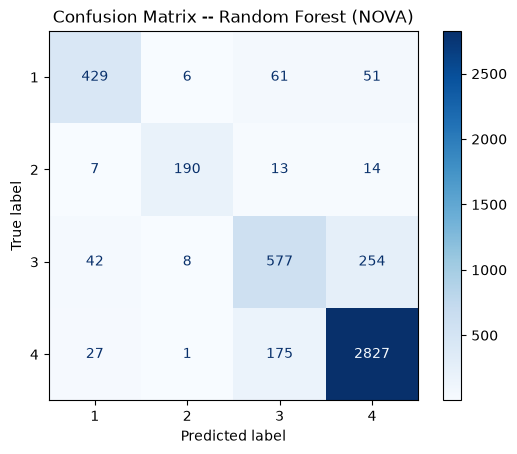

In [45]:
# Confusion matrix of the strongest model (by f1_weighted)
best_model_name = results_nova_df.iloc[0]["model"]
best_pipeline = fitted_pipelines_nova[best_model_name]

y_pred_best = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best, labels=sorted(y.unique()))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix -- {best_model_name} (NOVA)")
plt.show()

The confusion matrix of the Random Forest provides a more detailed view of the model's prediction performance across the four NOVA groups. Most observations lie on the main diagonal, indicating that the majority of products are correctly classified.

The model predicts NOVA Groups 2 and 4 particularly well. Group 2 exhibits very few misclassifications, while Group 4 achieves the largest number of correct predictions (2,827 out of 3,030 test observations), reflecting both its distinctive feature patterns and its prevalence in the dataset.

In contrast, NOVA Group 3 remains the most challenging class. The largest source of error occurs between Groups 3 and 4, where 254 Group 3 products are classified as Group 4 and 175 Group 4 products are classified as Group 3. This pattern suggests that moderately processed and ultra-processed foods share similar nutrient and ingredient characteristics, making them more difficult to distinguish than the less processed groups.

Misclassifications between Groups 1 and 2 are comparatively rare, indicating that the model is generally able to differentiate minimally processed foods from processed culinary ingredients. Likewise, very few observations are confused between Groups 1 and 4 or between Groups 2 and 4, suggesting that the Random Forest successfully captures the major differences between the extremes of the NOVA classification.

Overall, the confusion matrix confirms that the Random Forest not only achieves the highest overall predictive performance but also provides balanced classification across the four NOVA groups. The remaining prediction errors are concentrated primarily between the adjacent processing levels represented by Groups 3 and 4.

## 13. Model Comparison (NOVA)

The performance of the six baseline models is compared using multiple evaluation metrics. Because the NOVA classes are moderately imbalanced, the weighted F1-score serves as the primary evaluation metric, as it accounts for both precision and recall while considering the class distribution. Accuracy, weighted precision, and weighted recall are reported as complementary measures to provide a comprehensive assessment of model performance.

### 13.1 Comparison of the Baseline Models

The comparison of the six baseline models confirms that ensemble methods provide the strongest predictive performance for NOVA classification.

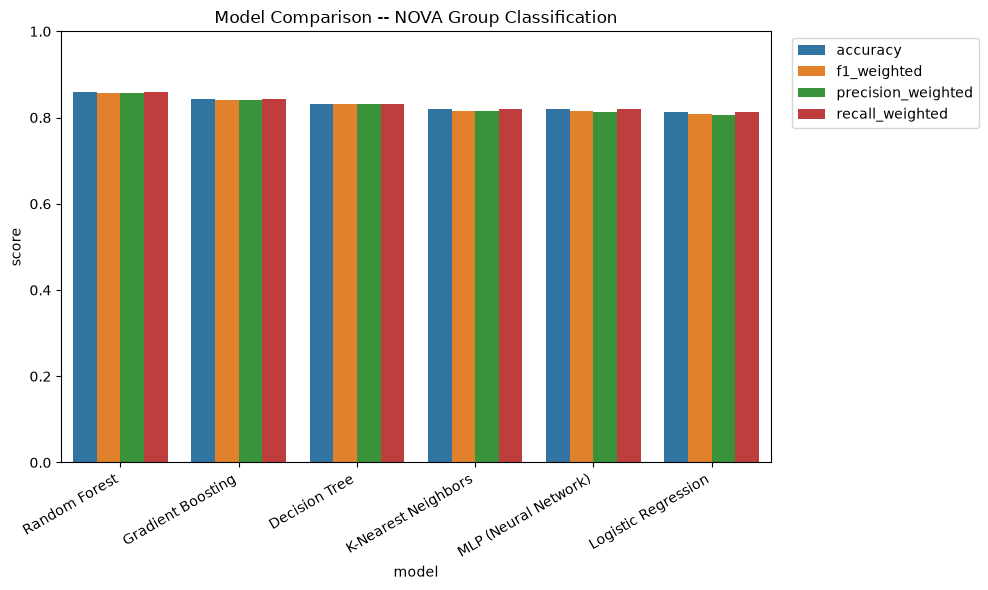

In [46]:
plt.figure(figsize=(10, 6))
results_melted = results_nova_df.melt(
    id_vars="model",
    value_vars=["accuracy", "f1_weighted", "precision_weighted", "recall_weighted"],
    var_name="metric", value_name="score"
)
sns.barplot(data=results_melted, x="model", y="score", hue="metric")
plt.xticks(rotation=30, ha="right")
plt.title("Model Comparison -- NOVA Group Classification")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Random Forest achieved the highest weighted F1-score (0.857), followed by Gradient Boosting (0.841) and the Decision Tree (0.831). The remaining models performed similarly, with K-Nearest Neighbors and the MLP Classifier both achieving weighted F1-scores of approximately 0.82, while Logistic Regression obtained the lowest score (0.808).

The ranking is consistent across all reported evaluation metrics, including accuracy, weighted precision, and weighted recall. This indicates that the superior performance of the Random Forest is not driven by a single metric but reflects a consistently stronger ability to classify products across the NOVA groups.

The comparatively weaker performance of Logistic Regression is consistent with the characteristics of the algorithm. As a linear classifier, Logistic Regression can only learn linear decision boundaries, whereas the relationship between food composition and processing level is likely to be highly nonlinear. In contrast, tree-based methods can naturally capture complex interactions among nutrients, ingredient counts, additive counts, and product categories, enabling them to model the hierarchical decision structure underlying the NOVA classification more effectively.

Overall, the comparison demonstrates that ensemble learning provides the most suitable approach for predicting food processing levels in the Open Food Facts dataset. Consequently, the Random Forest is selected for further analysis and hyperparameter tuning.

### 13.2 Feature Importance of the Best Baseline Model

The feature importance analysis of the Random Forest provides insight into which variables contribute most to the prediction of NOVA groups. 

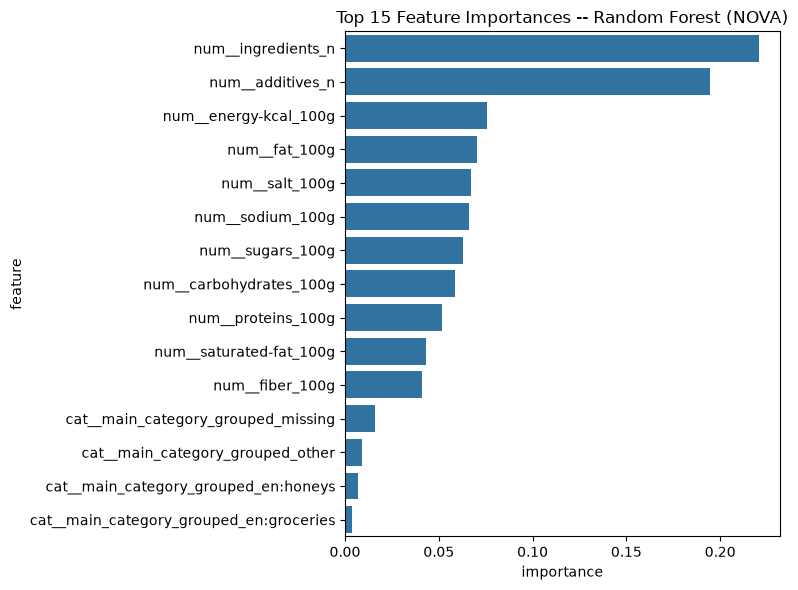

,feature,importance
10,num__ingredients_n,0.220823
9,num__additives_n,0.194375
0,num__energy-kcal_100g,0.075818
1,num__fat_100g,0.070154
7,num__salt_100g,0.067339
8,num__sodium_100g,0.066335
4,num__sugars_100g,0.062888
3,num__carbohydrates_100g,0.058486
6,num__proteins_100g,0.051696
2,num__saturated-fat_100g,0.043155


In [47]:
# Feature importances of the Random Forest pipeline (tests Hypothesis H1)
rf_pipeline = fitted_pipelines_nova["Random Forest"]
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({"feature": feature_names, "importance": importances}) \
    .sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importances -- Random Forest (NOVA)")
plt.tight_layout()
plt.show()

importance_df.head(15)


The two most influential predictors are `ingredients_n` (22.1%) and `additives_n` (19.4%), which together account for approximately **41.5%** of the total feature importance. Their combined contribution is substantially larger than that of any individual nutrient variable, with `energy-kcal_100g` ranking third at only 7.6%.

This finding strongly supports **Hypothesis H1**, which proposed that products containing a larger number of ingredients and additives are more likely to belong to higher NOVA groups, particularly Group 4. The dominance of these two variables is consistent with the conceptual foundation of the NOVA classification, which defines ultra-processed foods primarily according to the extent of industrial processing and the use of additives rather than nutrient composition alone (Monteiro et al., 2016).

The remaining nutrient variables, including energy, fat, salt, sodium, sugars, carbohydrates, protein, saturated fat, and fiber, also contribute to the classification, but each individually accounts for less than 8% of the total importance. Category-related variables exhibit only minor importance, suggesting that product composition provides considerably more predictive information than broad product categories.

These results are consistent with previous research. Menichetti et al. (2023) likewise found that ingredient- and additive-related information represents some of the strongest predictors for machine-learning models designed to classify food processing levels in large food databases. Overall, the feature importance analysis demonstrates that the Random Forest bases its predictions primarily on characteristics that directly reflect the underlying definition of the NOVA classification.

### 13.3 Leakage Check: Control Model Using Nutrient Features Only

The feature importance analysis showed that `ingredients_n` and `additives_n` are the two most influential predictors of NOVA classification. However, because the Open Food Facts `nova_group` labels are themselves derived from information related to ingredients, additives, and product categories, these variables introduce a **potential target leakage risk**. In other words, the model may partly reconstruct aspects of the labeling procedure rather than relying solely on independent relationships between nutrient composition and food processing level.

To investigate this possibility, a leakage check is performed using the two most contrasting model types from the previous section: Random Forest and Logistic Regression. Both models are retrained using only the nine nutrient variables (`energy-kcal_100g`, `fat_100g`, `saturated-fat_100g`, `carbohydrates_100g`, `sugars_100g`, `fiber_100g`, `proteins_100g`, `salt_100g`, and `sodium_100g`), while `ingredients_n`, `additives_n`, and `main_category_grouped` are excluded.

Comparing these nutrient-only models with the full-feature models provides a robustness check of the previous results. More specifically, it assesses whether food processing levels can be predicted from nutrient composition alone or whether the strong predictive performance primarily depends on variables that are closely related to the construction of the NOVA labels.

In [48]:
%%time
# --- Leakage check: control model using ONLY the nine pure nutrient features ---
# additives_n, ingredients_n, and main_category_grouped are deliberately excluded here,
# since these are the features that overlap with how Open Food Facts itself computes
# nova_group (see Nova-Algorithmus_OpenFoodFacts.md and the caveat in Section 1.1).
numeric_cols_nutrients_only = nutrient_features  # the 9 nutrient features, no additives/ingredients/category

X_nutrients_only = df_model_nova[numeric_cols_nutrients_only]
y_nutrients_only = df_model_nova["nova_group_clean"].astype(int)

X_train_no, X_test_no, y_train_no, y_test_no = train_test_split(
    X_nutrients_only, y_nutrients_only, test_size=0.2, random_state=SEED, stratify=y_nutrients_only
)

preprocessor_nutrients_only = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_cols_nutrients_only),
    ]
)

control_models = {
    "Random Forest (nutrients only)": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "Logistic Regression (nutrients only)": LogisticRegression(max_iter=1000, random_state=SEED),
}

control_results = []
for name, model in control_models.items():
    _, res = train_and_evaluate(
        model, name, X_train_no, y_train_no, X_test_no, y_test_no, preprocessor_nutrients_only
    )
    control_results.append(res)

# Compare against the same two model types trained WITH additives_n/ingredients_n/category (Section 12)
full_feature_scores = results_nova_df.set_index("model")["f1_weighted"]

comparison_df = pd.DataFrame({
    "model_type": ["Random Forest", "Logistic Regression"],
    "f1_weighted (with additives_n + category)": [
        full_feature_scores["Random Forest"],
        full_feature_scores["Logistic Regression"],
    ],
    "f1_weighted (nutrients only)": [
        next(r["f1_weighted"] for r in control_results if r["model"] == "Random Forest (nutrients only)"),
        next(r["f1_weighted"] for r in control_results if r["model"] == "Logistic Regression (nutrients only)"),
    ],
})
comparison_df["drop_in_f1_points"] = (
    (comparison_df["f1_weighted (with additives_n + category)"] - comparison_df["f1_weighted (nutrients only)"]) * 100
).round(1)
comparison_df



=== Random Forest (nutrients only) ===
              precision    recall  f1-score   support

           1       0.75      0.62      0.68       547
           2       0.85      0.75      0.80       224
           3       0.63      0.32      0.42       881
           4       0.78      0.92      0.85      3030

    accuracy                           0.77      4682
   macro avg       0.75      0.65      0.69      4682
weighted avg       0.75      0.77      0.74      4682


=== Logistic Regression (nutrients only) ===
              precision    recall  f1-score   support

           1       0.67      0.25      0.37       547
           2       0.80      0.53      0.64       224
           3       0.29      0.00      0.01       881
           4       0.69      0.97      0.80      3030

    accuracy                           0.69      4682
   macro avg       0.61      0.44      0.46      4682
weighted avg       0.61      0.69      0.60      4682

CPU times: user 7.54 s, sys: 101 ms, total: 

,model_type,f1_weighted (with additives_n + category),f1_weighted (nutrients only),drop_in_f1_points
0,Random Forest,0.857334,0.744206,11.3
1,Logistic Regression,0.807519,0.596083,21.1


Removing `ingredients_n`, `additives_n`, and `main_category_grouped` led to a substantial decline in predictive performance for both evaluated models. The weighted F1-score of the Random Forest decreased from 0.857 to 0.744, corresponding to a reduction of 11.3 percentage points. The Logistic Regression model showed an even larger decline, from 0.808 to 0.596, or 21.1 percentage points.

The nutrient-only Random Forest continued to achieve a comparatively strong weighted F1-score of 0.744, indicating that nutrient composition contains meaningful information about food processing level. However, its class-specific performance deteriorated substantially, particularly for NOVA Group 3, whose F1-score decreased to 0.42. Group 4 remained the easiest class to identify, with an F1-score of 0.85, while Groups 1 and 2 achieved F1-scores of 0.68 and 0.80, respectively.

The nutrient-only Logistic Regression performed considerably worse. Its weighted F1-score declined to 0.596, and it almost completely failed to identify NOVA Group 3, with a recall close to zero and an F1-score of 0.01. At the same time, the model classified most observations as Group 4, which resulted in a high recall for the majority class but weak discrimination across the full set of NOVA groups.

These results show that ingredient, additive, and category information contributes substantially to NOVA prediction. The performance reduction is consistent with the presence of a potential target-leakage risk because these variables are closely related to the information used to construct the Open Food Facts NOVA labels. Nevertheless, the nutrient-only Random Forest still performs clearly above a naive majority-class prediction, suggesting that the original results are not explained exclusively by leakage and that nutrient profiles also contain genuine information about processing level.

Overall, the leakage check qualifies the interpretation of the full-feature model. Its high predictive performance should not be understood as evidence that NOVA groups can be reconstructed from nutrient composition alone. Instead, the model benefits strongly from variables that reflect product formulation and overlap conceptually with the NOVA classification procedure.

## 14. Hyperparameter Tuning

To improve predictive performance beyond the baseline configurations, the two strongest NOVA classification models—Random Forest and Gradient Boosting—are optimized using `GridSearchCV`. The tuning procedure applies five-fold stratified cross-validation to preserve the NOVA class distribution within each fold and uses the weighted F1-score as the optimization criterion.

For each model, multiple combinations of selected hyperparameters are evaluated exclusively on the training data. The best-performing parameter configuration is then refitted on the complete training set and assessed on the unchanged test set. Comparing the tuned models with their baseline versions shows whether hyperparameter optimization produces a genuine improvement in out-of-sample performance.

### 14.1 Random Forest Hyperparameter Tuning

The baseline Random Forest is optimized using an exhaustive grid search to determine whether its predictive performance can be further improved. Three hyperparameters are tuned: the number of trees (`n_estimators`), the maximum tree depth (`max_depth`), and the minimum number of samples required at a leaf node (`min_samples_leaf`).

The optimal parameter combination is identified using `GridSearchCV` with five-fold stratified cross-validation, where the weighted F1-score serves as the optimization criterion. After selecting the best-performing configuration, the tuned model is evaluated on the unchanged test set to assess whether hyperparameter tuning leads to improved out-of-sample performance compared with the baseline Random Forest.

In [49]:
%%time
# Tune Random Forest
rf_param_grid = {
    "classifier__n_estimators": [200, 400],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_leaf": [1, 3, 5],
}

rf_pipeline_untuned = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=SEED, n_jobs=-1)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rf_grid = GridSearchCV(
    rf_pipeline_untuned, rf_param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best CV f1_weighted:", round(rf_grid.best_score_, 4))

y_pred_rf_tuned = rf_grid.predict(X_test)
print("\nTest set performance (tuned):")
print(classification_report(y_test, y_pred_rf_tuned, zero_division=0))


Best Random Forest parameters: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 400}
Best CV f1_weighted: 0.8666

Test set performance (tuned):
              precision    recall  f1-score   support

           1       0.85      0.78      0.82       547
           2       0.93      0.86      0.89       224
           3       0.70      0.65      0.67       881
           4       0.90      0.93      0.91      3030

    accuracy                           0.86      4682
   macro avg       0.84      0.81      0.82      4682
weighted avg       0.86      0.86      0.86      4682

CPU times: user 7.29 s, sys: 325 ms, total: 7.61 s
Wall time: 41.6 s


The Random Forest was tuned using a grid of values for the number of trees, maximum tree depth, and minimum number of samples required at a leaf node. The best-performing configuration used 400 trees, a maximum depth of 20, and a minimum leaf size of 1. This parameter combination achieved a weighted F1-score of 0.8666 during five-fold stratified cross-validation.

When evaluated on the unchanged test set, the tuned Random Forest achieved an accuracy and weighted F1-score of approximately 0.86. Its class-specific performance remained strongest for NOVA Groups 2 and 4, while Group 3 continued to be the most difficult class to predict.

Compared with the baseline Random Forest, which achieved a weighted F1-score of 0.8573, the tuned model produced only a very small improvement. The limited change indicates that the baseline configuration was already close to optimal for this dataset. Nevertheless, the tuning procedure confirms that a moderately constrained forest with a larger number of trees provides the strongest cross-validated performance among the tested parameter combinations.

### 14.2 Gradient Boosting Hyperparameter Tuning

The baseline Gradient Boosting model is optimized using a grid search to determine whether its predictive performance can be further improved. Three hyperparameters are tuned: the number of boosting stages (`n_estimators`), the learning rate (`learning_rate`), and the maximum depth of the individual regression trees (`max_depth`).

As for the Random Forest, the optimal parameter combination is identified using `GridSearchCV` with five-fold stratified cross-validation, where the weighted F1-score serves as the optimization criterion. The best-performing model is subsequently evaluated on the unchanged test set and compared with the baseline Gradient Boosting model to assess the effect of hyperparameter tuning on out-of-sample performance.

In [50]:
%%time
# Tune Gradient Boosting
gb_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [2, 3, 4],
}

gb_pipeline_untuned = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=SEED)),
])

gb_grid = GridSearchCV(
    gb_pipeline_untuned, gb_param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1
)
gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting parameters:", gb_grid.best_params_)
print("Best CV f1_weighted:", round(gb_grid.best_score_, 4))

y_pred_gb_tuned = gb_grid.predict(X_test)
print("\nTest set performance (tuned):")
print(classification_report(y_test, y_pred_gb_tuned, zero_division=0))

Best Gradient Boosting parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__n_estimators': 200}
Best CV f1_weighted: 0.8658

Test set performance (tuned):
              precision    recall  f1-score   support

           1       0.81      0.78      0.80       547
           2       0.91      0.84      0.88       224
           3       0.69      0.64      0.67       881
           4       0.90      0.93      0.91      3030

    accuracy                           0.85      4682
   macro avg       0.83      0.80      0.81      4682
weighted avg       0.85      0.85      0.85      4682

CPU times: user 22.7 s, sys: 191 ms, total: 22.9 s
Wall time: 2min 32s


The optimal Gradient Boosting configuration consisted of 200 boosting stages, a learning rate of 0.1, and a maximum tree depth of 4. This parameter combination achieved a weighted F1-score of 0.8658 during five-fold stratified cross-validation.

When evaluated on the unchanged test set, the tuned Gradient Boosting model achieved an accuracy and weighted F1-score of approximately 0.85. Similar to the baseline model, NOVA Groups 2 and 4 were classified with the highest accuracy, whereas Group 3 remained the most challenging class to distinguish.

Compared with the baseline Gradient Boosting model, which achieved a weighted F1-score of 0.8414, the tuned model improved to approximately 0.85, representing a modest but consistent increase in predictive performance. The results indicate that increasing the model complexity through a larger number of boosting stages and deeper trees allows Gradient Boosting to capture additional nonlinear relationships within the data while maintaining good generalization performance.

Although hyperparameter tuning improved the Gradient Boosting model, its performance remained slightly below that of the tuned Random Forest. Consequently, the Random Forest continues to represent the strongest overall model for NOVA classification.

### 14.3 Comparison of Baseline and Tuned Models

The effects of hyperparameter tuning are evaluated by comparing the weighted F1-scores of the baseline and tuned Random Forest and Gradient Boosting models on the unchanged test set. Using the same test observations ensures that any differences in performance can be attributed to the selected model configurations rather than to changes in the evaluation data.

The comparison provides a direct assessment of whether the cross-validation-based tuning procedure improved out-of-sample classification performance. The results are presented both numerically and visually to make even small differences between the baseline and tuned models apparent.

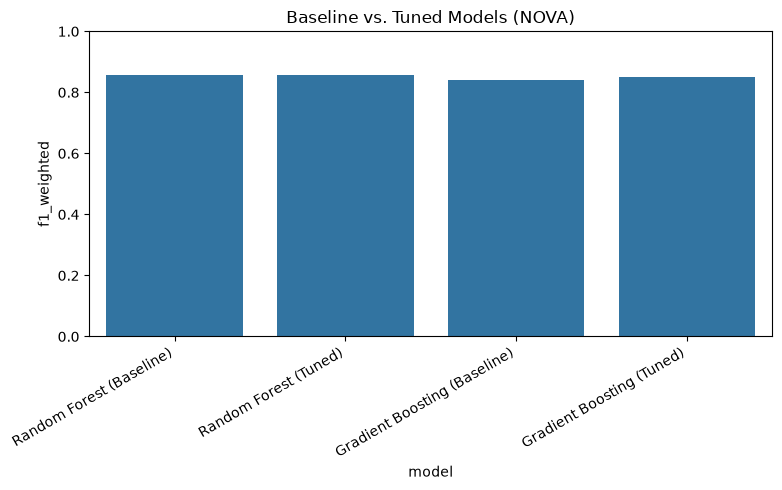

,model,f1_weighted
0,Random Forest (Baseline),0.857334
1,Random Forest (Tuned),0.856086
2,Gradient Boosting (Baseline),0.841364
3,Gradient Boosting (Tuned),0.849411


In [51]:
# Comparison: tuned vs. untuned
tuning_comparison = pd.DataFrame([
    {"model": "Random Forest (Baseline)", "f1_weighted": results_nova_df.set_index("model").loc["Random Forest", "f1_weighted"]},
    {"model": "Random Forest (Tuned)", "f1_weighted": f1_score(y_test, y_pred_rf_tuned, average="weighted")},
    {"model": "Gradient Boosting (Baseline)", "f1_weighted": results_nova_df.set_index("model").loc["Gradient Boosting", "f1_weighted"]},
    {"model": "Gradient Boosting (Tuned)", "f1_weighted": f1_score(y_test, y_pred_gb_tuned, average="weighted")},
])

plt.figure(figsize=(8, 5))
sns.barplot(data=tuning_comparison, x="model", y="f1_weighted")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.title("Baseline vs. Tuned Models (NOVA)")
plt.tight_layout()
plt.show()

tuning_comparison


Hyperparameter tuning produced different outcomes for the two ensemble models. The weighted F1-score of the Random Forest decreased marginally from 0.8573 in the baseline model to 0.8561 after tuning, corresponding to a reduction of approximately 0.0012. This difference is negligible and indicates that the default Random Forest configuration already performed close to optimally on the test set. Although the tuned configuration achieved the highest score during cross-validation, this improvement did not transfer to the unseen test data.

In contrast, the Gradient Boosting model improved from a weighted F1-score of 0.8414 to 0.8494, representing an increase of approximately 0.0080. The tuned parameter configuration therefore improved the model's ability to generalize to the test set, although the gain remained relatively modest.

Overall, the baseline Random Forest retained the highest test-set weighted F1-score among the four evaluated configurations. The results demonstrate that hyperparameter tuning does not automatically improve out-of-sample performance and underline the importance of evaluating the final model on a separate test set rather than relying exclusively on cross-validation results.

## 15. Nutri-Score Classification (Secondary Problem)

In addition to the primary task of predicting NOVA groups, a secondary classification problem is considered by predicting Nutri-Score grades. This analysis serves as a benchmark that complements the NOVA classification and allows the predictive difficulty of both food labeling systems to be compared.

Unlike NOVA, the Nutri-Score algorithm is primarily based on nutritional composition. Consequently, only the nine nutrient features are used for model development, while variables such as the number of ingredients, number of additives, and product category are deliberately excluded because they are not part of the Nutri-Score calculation.

To reflect its role as a secondary research problem, the analysis is limited to three representative classification models: Logistic Regression, Random Forest, and a multilayer perceptron (MLP) neural network. These models provide a meaningful comparison between a linear baseline, a tree-based ensemble method, and a nonlinear deep learning approach while maintaining a more focused scope than the primary NOVA classification task.

Based on the design of the Nutri-Score algorithm, higher predictive performance is expected than for NOVA classification. If confirmed, this would support Hypothesis H2 and demonstrate that nutrient-based features are highly informative for predicting Nutri-Score grades.

### 15.1 Nutri-Score Model Training and Evaluation

Three supervised classification models are evaluated for predicting Nutri-Score grades: Logistic Regression, Random Forest, and an MLP neural network. The models are selected to represent a linear baseline, a tree-based ensemble method, and a nonlinear deep learning approach.

Only the nine nutrient features are used as predictors. The data are divided into stratified training and test sets to preserve the distribution of the five Nutri-Score classes. Numerical preprocessing consists of median imputation followed by standardization, and the same preprocessing pipeline is applied consistently to all three models.

Model performance is assessed on the unchanged test set using accuracy, weighted precision, weighted recall, and the weighted F1-score. The weighted F1-score serves as the primary comparison metric because it accounts for both precision and recall while considering differences in class frequency.

In [52]:
%%time
# Preprocessing analogous to Section 10, but using only the 9 nutrient features
X_nutri = df_model_nutri[nutrient_features]
y_nutri = df_model_nutri["nutriscore_grade"]

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_nutri, y_nutri, test_size=0.2, random_state=SEED, stratify=y_nutri
)

preprocessor_nutri = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), nutrient_features),
    ]
)

models_nutri = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "MLP (Neural Network)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=SEED, early_stopping=True),
}

results_nutri = []
for name, model in models_nutri.items():
    _, res = train_and_evaluate(model, name, X_train_n, y_train_n, X_test_n, y_test_n, preprocessor_nutri)
    results_nutri.append(res)

results_nutri_df = pd.DataFrame(results_nutri).sort_values("f1_weighted", ascending=False)
results_nutri_df



=== Logistic Regression ===
              precision    recall  f1-score   support

           a       0.62      0.76      0.68       830
           b       0.46      0.23      0.31       674
           c       0.54      0.66      0.59      1222
           d       0.69      0.64      0.66      1467
           e       0.80      0.79      0.79      1592

    accuracy                           0.65      5785
   macro avg       0.62      0.61      0.61      5785
weighted avg       0.65      0.65      0.64      5785


=== Random Forest ===
              precision    recall  f1-score   support

           a       0.77      0.83      0.80       830
           b       0.70      0.63      0.67       674
           c       0.77      0.79      0.78      1222
           d       0.86      0.87      0.87      1467
           e       0.92      0.90      0.91      1592

    accuracy                           0.83      5785
   macro avg       0.81      0.80      0.80      5785
weighted avg       0.83  

,model,accuracy,f1_weighted,precision_weighted,recall_weighted
1,Random Forest,0.827312,0.826895,0.827397,0.827312
2,MLP (Neural Network),0.787381,0.788971,0.792426,0.787381
0,Logistic Regression,0.653587,0.644843,0.650107,0.653587


The Random Forest achieved the strongest overall performance, with an accuracy of 0.8273 and a weighted F1-score of 0.8269. It outperformed both the MLP neural network and Logistic Regression across all reported aggregate metrics. The model performed particularly well for Nutri-Score grades D and E, with class-specific F1-scores of 0.87 and 0.91, respectively.

The MLP classifier ranked second, achieving an accuracy of 0.7874 and a weighted F1-score of 0.7890. Its performance was also strongest for grades D and E, while grade B remained comparatively difficult to classify. Although the neural network captured nonlinear relationships more effectively than Logistic Regression, it did not surpass the Random Forest.

Logistic Regression produced the weakest results, with an accuracy of 0.6536 and a weighted F1-score of 0.6448. Its particularly low F1-score of 0.31 for grade B indicates that the relationships between nutrient composition and Nutri-Score are not adequately represented by simple linear decision boundaries.

Across all three models, Nutri-Score grade B was the most difficult class to predict, whereas grades D and E were classified most reliably. This pattern suggests that products in the middle of the Nutri-Score scale have more overlapping nutrient profiles, while products with less favorable nutritional compositions are more clearly distinguishable.

Contrary to the expectation formulated in Hypothesis H2, Nutri-Score classification did not outperform the best NOVA model. The Random Forest achieved a weighted F1-score of 0.8269 for Nutri-Score, compared with 0.8573 for the baseline NOVA Random Forest. Hypothesis H2 is therefore not supported by the observed test-set results. Nevertheless, the Nutri-Score models relied exclusively on nutrient features, whereas the NOVA models benefited from additional formulation-related variables such as ingredient and additive counts, which likely contributed to their higher predictive performance.

### 15.2 Direct Comparison of NOVA and Nutri-Score Performance

To evaluate Hypothesis H2 directly, the best-performing model from the NOVA classification task is compared with the best-performing model from the Nutri-Score classification task. In both cases, the comparison is based on the weighted F1-score obtained on the respective unseen test set.

This comparison assesses whether Nutri-Score can be predicted more accurately from nutrient information than NOVA can be predicted from the full feature set. Because both tasks involve different target variables and slightly different sample compositions, the results should be interpreted as a practical benchmark rather than as a perfectly controlled statistical comparison.

In [53]:
# Direct comparison: best NOVA score vs. best Nutri-Score score (tests H2)
comparison = pd.DataFrame([
    {"Problem": "NOVA (main problem)", "Best model": results_nova_df.iloc[0]["model"], "f1_weighted": results_nova_df.iloc[0]["f1_weighted"]},
    {"Problem": "Nutri-Score (secondary problem)", "Best model": results_nutri_df.iloc[0]["model"], "f1_weighted": results_nutri_df.iloc[0]["f1_weighted"]},
])
comparison


,Problem,Best model,f1_weighted
0,NOVA (main problem),Random Forest,0.857334
1,Nutri-Score (secondary problem),Random Forest,0.826895


Random Forest was the best-performing model for both classification tasks. For NOVA prediction, the baseline Random Forest achieved a weighted F1-score of 0.8573, whereas the Random Forest used for Nutri-Score classification achieved 0.8269.

The NOVA model therefore outperformed the Nutri-Score model by approximately 0.0304, or 3.0 percentage points. This finding is contrary to Hypothesis H2, which expected Nutri-Score classification to achieve noticeably higher predictive performance because Nutri-Score is calculated largely from nutrient information.

Hypothesis H2 is therefore not supported. However, the comparison must be interpreted in light of the different feature sets. The NOVA model used nutrient variables together with ingredient counts, additive counts, and product-category information, whereas the Nutri-Score model relied exclusively on nutrient features. The strong predictive contribution of the formulation-related NOVA features likely explains why the NOVA model achieved the higher weighted F1-score despite the broader conceptual complexity of the NOVA classification system.

## 16. Conclusion

### 16.1 Evaluation of the Hypotheses

The results provide varying levels of support for the four hypotheses proposed at the beginning of this project.

- **H1 (Ingredients and additives are important predictors of NOVA groups) – Confirmed.**  
  The Random Forest feature importance analysis identified `ingredients_n` (22.1%) and `additives_n` (19.4%) as the two most influential predictors, accounting for approximately 41.5% of the total feature importance. This finding is consistent with the conceptual definition of the NOVA classification, which emphasizes food formulation and processing rather than nutritional composition alone (Monteiro et al., 2016), and agrees with previous machine learning studies on food processing classification (Menichetti et al., 2023).

- **H2 (Nutri-Score is easier to predict than NOVA) – Not supported.**  
  Contrary to expectations, the best NOVA model achieved a higher weighted F1-score (0.8573) than the best Nutri-Score model (0.8269). This result is primarily explained by the richer feature set available for NOVA classification, which includes ingredient counts, additive counts, and product-category information in addition to nutrient features. Consequently, the comparison demonstrates that predictive performance depends not only on the complexity of the target variable but also on the information available to the model.

- **H3 (Nutri-Score and NOVA do not exhibit a one-to-one relationship) – Confirmed.**  
  The cross-tabulation showed that 27% of products with Nutri-Score A belong to NOVA Group 4, while this proportion increases to 77% for products with Nutri-Score E. These findings closely resemble published analyses of the Open Food Facts database, which reported corresponding values of 26.1% and 83.7%, respectively (Romero Ferreiro et al., 2021), with a similar monotonic trend observed by Sarda et al. (2024). The results demonstrate that nutritional quality and degree of processing capture related but distinct aspects of food quality.

- **H4 (Nutrient-based clusters resemble Nutri-Score more closely than NOVA) – Confirmed, although the relationship is weak.**  
  The clustering analysis yielded an Adjusted Rand Index of 0.0805 with Nutri-Score and 0.0290 with NOVA. Although both agreements are relatively low, the stronger alignment with Nutri-Score indicates that nutrient-based clustering captures nutritional similarities more effectively than processing-related characteristics, which are fundamental to the NOVA classification.

### 16.2 Model Comparison

Random Forest consistently achieved the strongest predictive performance for both classification tasks. For NOVA classification, the baseline Random Forest obtained the highest weighted F1-score (0.8573), while hyperparameter tuning resulted in virtually identical performance (0.8561), indicating that the baseline configuration was already close to optimal. For Nutri-Score classification, Random Forest again outperformed the alternative models with a weighted F1-score of 0.8269.

Among the remaining models, Gradient Boosting benefited most from hyperparameter optimization, improving from a weighted F1-score of 0.8414 to 0.8494. Nevertheless, it did not surpass the Random Forest. Logistic Regression consistently produced the weakest performance for both prediction tasks, suggesting that the relationships between the predictor variables and the target classes are predominantly nonlinear. The superior performance of the tree-based ensemble models is also consistent with the correlation structure observed during exploratory data analysis, where several nutrient variables exhibited moderate to strong correlations.

### 16.3 Limitations

Several limitations should be considered when interpreting the results.

- Although the dataset comprises 100,000 randomly sampled products, this still represents only a small proportion of the complete Open Food Facts database containing more than 4.6 million products.
- Products containing implausible nutrient values were removed entirely during data cleaning. While this conservative strategy improves data quality, it also reduces the available sample size and may exclude products that could otherwise have been retained through selective imputation.
- Missing values in Open Food Facts are not randomly distributed. The availability of NOVA and Nutri-Score labels varies considerably across countries, resulting in a dataset that is disproportionately composed of products from countries where these labels are more frequently available.
- Product category information is highly incomplete, with many products lacking usable category assignments or being grouped into a broad "other" category, limiting the usefulness of this feature.
- Class imbalance remains relevant because NOVA Group 2 is the least represented class, with only 224 observations in the test set. However, the classification results show that Group 3 is the most difficult class to predict, mainly because it is frequently confused with Group 4. The performance of both classes should therefore be interpreted carefully, although for different reasons: Group 2 because of its small sample size and Group 3 because of its substantial class overlap.
- The NOVA target labels are themselves derived from information such as ingredients, additives, and product categories. Although the control model presented in Section 13 demonstrated that nutrient features alone still contain substantial predictive information, the inclusion of formulation-related variables introduces a potential target leakage risk that should be considered when interpreting the exceptionally strong performance of the full-feature models.
- The comparison between NOVA and Nutri-Score classification intentionally uses different feature sets to reflect the conceptual differences between the two labeling systems. Consequently, the comparison should be interpreted as a practical benchmark rather than a perfectly controlled experimental comparison.

### 16.4 Overall Conclusion

This project demonstrates that machine learning models can successfully predict the NOVA processing group of a food product from its nutrient values together with information on the number of ingredients and additives. The best-performing Random Forest model achieved a weighted F1-score of 0.8573 on unseen test data, indicating that these variables provide sufficient information for accurate NOVA classification.

The analyses further show that nutritional composition alone is insufficient to fully characterize food processing. Ingredients and additives were identified as the dominant predictors of NOVA classification, whereas nutrient-based clustering aligned only weakly with NOVA but more closely with Nutri-Score. These findings reinforce the conceptual distinction between nutritional quality and food processing and illustrate why both labeling systems provide complementary information rather than interchangeable assessments of food products.

**Overall, the results answer the main research question affirmatively: NOVA processing groups can be predicted with high accuracy using machine learning when nutrient information is complemented by ingredient and additive information, with Random Forest providing the strongest overall performance.**

### 16.5 Practical Implication

To illustrate a potential practical application of the project, a consumer-facing web prototype named **NutriVision** was developed. The application allows users to upload a nutrition label or manually enter nutritional values, together with the number of listed ingredients and identified additives. It presents estimated Nutri-Score and NOVA classifications, an intuitive overall food quality rating, and suggestions for potentially healthier alternatives.

The prototype demonstrates how the analytical approach developed in this project could be translated into an accessible decision-support application. It is intended primarily as a conceptual demonstration of a possible user interface and application scenario.

Disclaimer: The prototype was created separately using the AI-assisted development platform Lovable and is not technically connected to the trained models or execution pipeline contained in this notebook. Its predictions, overall ratings, image-recognition outputs, and alternative recommendations are therefore illustrative and should not be interpreted as reproductions of the validated notebook results. The application is intended solely for educational and demonstration purposes and does not provide medical or professional nutritional advice.

The prototype can be accessed here:

**[Open NutriVision](https://food-clarity-engine.lovable.app)** 

## References

Bauer, J., Biolo, G., Cederholm, T., Cesari, M., Cruz-Jentoft, A. J., Morley, J. E., Phillips, S., Sieber, C., Stehle, P., Teta, D., Visvanathan, R., Volpi, E., & Boirie, Y. (2013). Evidence-based recommendations for optimal dietary protein intake in older people: A position paper from the PROT-AGE Study Group. Journal of the American Medical Directors Association, 14(8), 542-559. https://doi.org/10.1016/j.jamda.2013.05.021

European Commission (2026). Dietary salt/sodium. knowledge4policy.ec.europa.eu. https://knowledge4policy.ec.europa.eu/health-promotion-knowledge-gateway/dietary-salt/sodium_en

Hubert, L., & Arabie, P. (1985). Comparing partitions. Journal of Classification, 2(1), 193-218. https://doi.org/10.1007/BF01908075

Hugging Face (2026). Open Food Facts Database. huggingface.co. https://huggingface.co/datasets/openfoodfacts/product-database

Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: A review and recent developments. Philosophical Transactions of the Royal Society A: Mathematical, Physical and Engineering Sciences, 374(2065), 20150202. https://doi.org/10.1098/rsta.2015.0202

MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. In L. M. Le Cam & J. Neyman (Eds.), Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability (Vol. 1, pp. 281–297). University of California Press.

Menichetti, G., Ravandi, B., Mozaffarian, D., & Barabasi, A.-L. (2023). Machine learning prediction of the degree of food processing. Nature Communications, 14, 2312. https://doi.org/10.1038/s41467-023-37457-1

Merz, B., Temme, E., Alexiou, H., Beulens, J. W. J., Buyken, A. E., Bohn, T., Ducrot, P., Falquet, M.-N., Garcia Solano, M., Haidar, H., Infanger, E., Kuhnelt, C., Rodriguez-Artalejo, F., Sarda, B., Steenbergen, E., Vandevijvere, S., & Julia, C. (2024). Nutri-Score 2023 update. Nature Food, 5, 102-110. https://doi.org/10.1038/s43016-024-00920-3

Milligan, G. W., & Cooper, M. C. (1988). A study of standardization of variables in cluster analysis. Journal of Classification, 5(2), 181–204. https://doi.org/10.1007/BF01897163

Monteiro, C. A., Cannon, G., Levy, R., Moubarac, J.-C., Jaime, P., Martins, A. P., Canella, D., Louzada, M., & Parra, D. (2016). NOVA. The star shines bright: Food classification. World Nutrition, 7(1-3), 28-38. https://worldnutritionjournal.org/wn/article/view/5

Monteiro, C. A., Cannon, G., Levy, R. B., Moubarac, J.-C., Louzada, M. L. C., Rauber, F., Khandpur, N., Cediel, G., Neri, D., Martinez-Steele, E., Baraldi, L. G., & Jaime, P. C. (2019). Ultra-processed foods: What they are and how to identify them. Public Health Nutrition, 22(5), 936–941. https://doi.org/10.1017/S1368980018003762

O'Hara, C., O'Sullivan, A., & Gibney, E. R. (2022). A clustering approach to meal-based analysis of dietary intakes applied to population and individual data. The Journal of Nutrition, 152(10), 2297–2308. https://doi.org/10.1093/jn/nxac147

Reynolds, A., Mann, J., Cummings, J., Winter, N., Mete, E., & Te Morenga, L. (2019). Carbohydrate quality and human health: A series of systematic reviews and meta-analyses. The Lancet, 393(10170), 434-445. https://doi.org/10.1016/S0140-6736(18)31809-9

Romero Ferreiro, C., Lora Pablos, D., & Gomez de la Camara, A. (2021). Two dimensions of nutritional value: Nutri-Score and NOVA. Nutrients, 13(8), 2783. https://doi.org/10.3390/nu13082783

Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. Journal of Computational and Applied Mathematics, 20, 53-65. https://doi.org/10.1016/0377-0427(87)90125-7

Salloum, S., Huang, J. Z., & He, Y. (2019). Random sample partition: A distributed data model for big data analysis. IEEE Transactions on Industrial Informatics, 15(11), 5846-5855. https://doi.org/10.1109/TII.2019.2912720

Sarda, B., Kesse-Guyot, E., Deschamps, V., Ducrot, P., Galan, P., Hercberg, S., Deschasaux-Tanguy, M., Srour, B., Fezeu, L. K., Touvier, M., & Julia, C. (2024). Complementarity between the updated version of the front-of-pack nutrition label Nutri-Score and the food-processing NOVA classification. Public Health Nutrition, 27(1), e63. https://doi.org/10.1017/S1368980024000296

Snetselaar, L. G., de Jesus, J. M., DeSilva, D. M., & Stoody, E. E. (2021). Dietary Guidelines for Americans, 2020-2025: Understanding the scientific process, guidelines, and key recommendations. Nutrition Today, 56(6), 287-295. https://doi.org/10.1097/NT.0000000000000512

van der Bend, D. L. M., van Eijsden, M., van Roost, M. H. I., de Graaf, K., & Roodenburg, A. J. C. (2022). The Nutri-Score algorithm: Evaluation of its validation process. Frontiers in Nutrition, 9, Article 974003. https://doi.org/10.3389/fnut.2022.974003

Vitter, J. S. (1985). Random sampling with a reservoir. ACM Transactions on Mathematical Software, 11(1), 37–57. https://doi.org/10.1145/3147.3165

World Health Organization (2026). Healthy diet. who.int. https://www.who.int/news-room/fact-sheets/detail/healthy-diet
